# Robust ML-Based Spectrum Occupancy Detection
### A simulation-based comparison of feature-based machine learning vs classical energy detection

This notebook builds the project step by step. Each section narrates *what* we are
doing and *why*, then runs the code (imported from the `src/` package).

**Research question:** How robust are feature-based ML spectrum-sensing models when
SNR, modulation, and channel conditions change?

**Signal model (binary hypothesis test on each received window):**

$$H_0:\; y[n] = w[n] \quad\text{(free, noise only, label 0)}$$
$$H_1:\; y[n] = h[n]\,s[n] + w[n] \quad\text{(occupied, signal present, label 1)}$$


## 0. Setup and environment check
Import libraries and the project package, fix a global random seed for
reproducibility, and confirm versions. Run this cell first, every session.

In [3]:
# Standard scientific stack
import numpy as np
import scipy
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt

# Make src/ importable, then (later) import our own modules
import sys, os
sys.path.append(os.path.abspath("."))

# Global seed for reproducibility (the same seed -> the same dataset every run)
SEED = 42
rng = np.random.default_rng(SEED)

print("Environment:")
print(f"  numpy        {np.__version__}")
print(f"  scipy        {scipy.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  matplotlib   {matplotlib.__version__}")
print(f"  global seed  {SEED}")


Environment:
  numpy        2.4.6
  scipy        1.15.2
  pandas       2.2.3
  scikit-learn 1.6.1
  matplotlib   3.9.2
  global seed  42


## 1. Signal generation  (`src/signals.py`)
Generate the transmitted primary-user signal $s[n]$ for the occupied case:
sine, BPSK, QPSK, and 16-QAM, as unit-power complex baseband.

### 1.1 The sine carrier

The signal generators in `src/signals.py` produce the transmitted signal **s[n]**
(the thing present under H1, absent under H0). Two conventions apply to every
modulation:

1. **Complex baseband** — each sample is complex (I + jQ).
2. **Unit average power** — mean(|s[n]|²) = 1, so SNR is controlled entirely by
   the noise stage later, and all modulations are directly comparable.

The simplest occupied signal is an unmodulated sine carrier (a pure tone, a
carrier with no data on it):

$$s[n] = A \cdot e^{\,j(2\pi f n + \phi)}$$

Because a complex exponential has constant magnitude (|s[n]| = A for all n),
unit power means A = 1. We add a random start phase φ so each window differs.

In [64]:
from src.signals import generate_sine

# Generate one sine window using the seeded generator from Section 0
s_sine = generate_sine(n_samples=1024, rng=rng, f_norm=0.1)

print("dtype         :", s_sine.dtype)
print("shape         :", s_sine.shape)
print("average power :", np.mean(np.abs(s_sine)**2), "(should be 1.0)")

dtype         : complex128
shape         : (1024,)
average power : 1.0 (should be 1.0)


plot time and frequency

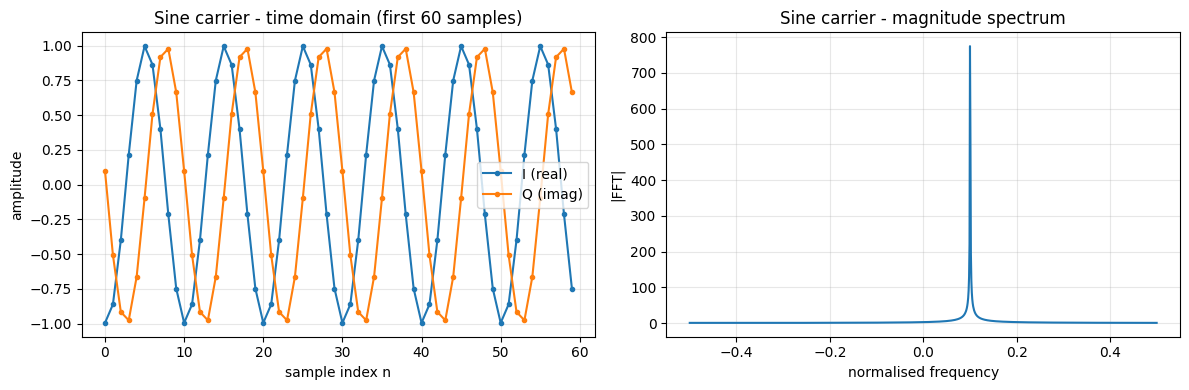

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Time domain: I and Q for the first 60 samples
ax[0].plot(s_sine.real[:60], label="I (real)", marker=".")
ax[0].plot(s_sine.imag[:60], label="Q (imag)", marker=".")
ax[0].set_title("Sine carrier - time domain (first 60 samples)")
ax[0].set_xlabel("sample index n"); ax[0].set_ylabel("amplitude")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

# Frequency domain: magnitude spectrum
spec  = np.abs(np.fft.fftshift(np.fft.fft(s_sine)))
freqs = np.fft.fftshift(np.fft.fftfreq(len(s_sine)))
ax[1].plot(freqs, spec)
ax[1].set_title("Sine carrier - magnitude spectrum")
ax[1].set_xlabel("normalised frequency"); ax[1].set_ylabel("|FFT|")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/sine_signal.png", dpi=110, bbox_inches="tight")
plt.show()

### 1.2 BPSK (Binary Phase Shift Keying)

Sine carries no data; BPSK carries one bit per symbol. We map each random bit
to one of two constellation points:

$$\text{bit } 0 \rightarrow -1+0j \qquad \text{bit } 1 \rightarrow +1+0j$$

Each symbol is held for `sps` samples ("rectangular pulse shaping"). With
`n_samples=1024` and `sps=8`, we transmit 128 random symbols.

Because every sample has $|s[n]| = 1$, the average power is already 1, so the
unit-power convention is satisfied automatically.

In [5]:
### import and generate
from src.signals import generate_bpsk

s_bpsk = generate_bpsk(n_samples=1024, rng=rng, sps=8)

print("dtype         :", s_bpsk.dtype)
print("shape         :", s_bpsk.shape)
print("average power :", np.mean(np.abs(s_bpsk)**2), "(should be 1.0)")
print("unique values :", np.unique(np.round(s_bpsk.real, 6)), "(BPSK -> just two)")

dtype         : complex128
shape         : (1024,)
average power : 1.0 (should be 1.0)
unique values : [-1.  1.] (BPSK -> just two)


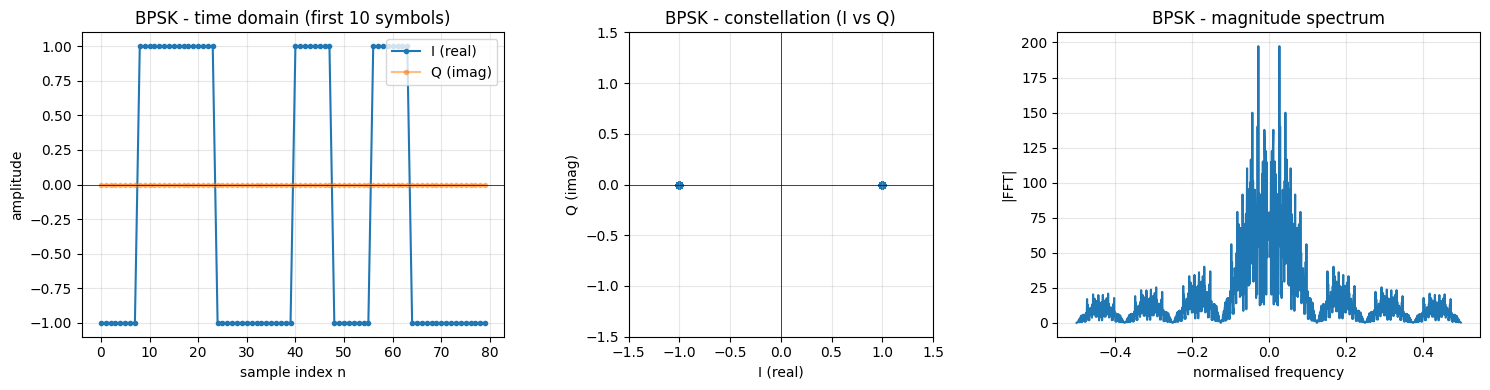

In [7]:
### plot time, constellation, and spectrum
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Time domain (first 80 samples = 10 symbols at sps=8)
ax[0].plot(s_bpsk.real[:80], marker=".", label="I (real)")
ax[0].plot(s_bpsk.imag[:80], marker=".", label="Q (imag)", alpha=0.5)
ax[0].set_title("BPSK - time domain (first 10 symbols)")
ax[0].set_xlabel("sample index n"); ax[0].set_ylabel("amplitude")
ax[0].legend(); ax[0].grid(True, alpha=0.3); ax[0].axhline(0, color="k", lw=0.5)

# Constellation (I vs Q)
ax[1].scatter(s_bpsk.real, s_bpsk.imag, alpha=0.3, s=20)
ax[1].set_title("BPSK - constellation (I vs Q)")
ax[1].set_xlabel("I (real)"); ax[1].set_ylabel("Q (imag)")
ax[1].set_xlim(-1.5, 1.5); ax[1].set_ylim(-1.5, 1.5)
ax[1].grid(True, alpha=0.3)
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)
ax[1].set_aspect("equal")

# Magnitude spectrum
spec  = np.abs(np.fft.fftshift(np.fft.fft(s_bpsk)))
freqs = np.fft.fftshift(np.fft.fftfreq(len(s_bpsk)))
ax[2].plot(freqs, spec)
ax[2].set_title("BPSK - magnitude spectrum")
ax[2].set_xlabel("normalised frequency"); ax[2].set_ylabel("|FFT|")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/bpsk_signal.png", dpi=110, bbox_inches="tight")
plt.show()

### 1.3 QPSK (Quadrature Phase Shift Keying)

QPSK uses both I and Q axes, carrying **two bits per symbol** instead of one.
The four constellation points are placed in the four quadrants of the complex
plane using Gray coding (adjacent points differ in only one bit):

$$00 \rightarrow +1+j \qquad 01 \rightarrow -1+j \qquad 11 \rightarrow -1-j \qquad 10 \rightarrow +1-j$$

Each unnormalised symbol has magnitude $\sqrt{2}$, so dividing by $\sqrt{2}$ brings
average power back to 1. After normalisation, the four points sit at
$\pm 1/\sqrt{2} \pm j/\sqrt{2}$, each at distance 1 from the origin.

In [ ]:
### import and generate
from src.signals import generate_qpsk

s_qpsk = generate_qpsk(n_samples=1024, rng=rng, sps=8)

print("dtype           :", s_qpsk.dtype)
print("shape           :", s_qpsk.shape)
print("average power   :", np.mean(np.abs(s_qpsk)**2), "(should be 1.0)")
uniq = np.unique(np.round(s_qpsk, 4))
print("unique symbols  :", uniq)
print("num unique pts  :", len(uniq), "(QPSK -> 4)")

In [ ]:
### plot
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Time domain (first 80 samples = 10 symbols at sps=8)
ax[0].plot(s_qpsk.real[:80], marker=".", label="I (real)")
ax[0].plot(s_qpsk.imag[:80], marker=".", label="Q (imag)", alpha=0.7)
ax[0].set_title("QPSK - time domain (first 10 symbols)")
ax[0].set_xlabel("sample index n"); ax[0].set_ylabel("amplitude")
ax[0].legend(); ax[0].grid(True, alpha=0.3); ax[0].axhline(0, color="k", lw=0.5)

# Constellation
ax[1].scatter(s_qpsk.real, s_qpsk.imag, alpha=0.3, s=20)
ax[1].set_title("QPSK - constellation (I vs Q)")
ax[1].set_xlabel("I (real)"); ax[1].set_ylabel("Q (imag)")
ax[1].set_xlim(-1.5, 1.5); ax[1].set_ylim(-1.5, 1.5)
ax[1].grid(True, alpha=0.3)
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)
ax[1].set_aspect("equal")

# Magnitude spectrum
spec  = np.abs(np.fft.fftshift(np.fft.fft(s_qpsk)))
freqs = np.fft.fftshift(np.fft.fftfreq(len(s_qpsk)))
ax[2].plot(freqs, spec)
ax[2].set_title("QPSK - magnitude spectrum")
ax[2].set_xlabel("normalised frequency"); ax[2].set_ylabel("|FFT|")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/qpsk_signal.png", dpi=110, bbox_inches="tight")
plt.show()

### 1.4 16-QAM (16-point Quadrature Amplitude Modulation)

The last modulation in the minimum-version set. Unlike BPSK and QPSK, which
only use **phase**, 16-QAM uses both **phase and amplitude**. The 16
constellation points form a 4-by-4 grid, with I and Q each taking one of four
Gray-coded levels $\{-3, -1, +1, +3\}$.

Each symbol carries **4 bits** ($\log_2 16 = 4$). The unnormalised average
symbol power is 10, so unit-power normalisation divides by $\sqrt{10}$.

After normalisation, the 16 points have **three distinct distances** from the
origin:
- 4 inner points at distance $\sqrt{2/10} \approx 0.447$
- 8 edge points at distance $\sqrt{10/10} = 1.000$
- 4 corner points at distance $\sqrt{18/10} \approx 1.342$

In [ ]:
### import and generate
from src.signals import generate_16qam

s_16qam = generate_16qam(n_samples=1024, rng=rng, sps=8)

print("dtype           :", s_16qam.dtype)
print("shape           :", s_16qam.shape)
print("average power   :", np.mean(np.abs(s_16qam)**2), "(should be 1.0)")
uniq = np.unique(np.round(s_16qam, 4))
print("num unique pts  :", len(uniq), "(16-QAM -> 16)")
print("unique |s|      :", np.unique(np.round(np.abs(uniq), 4)),
      "(three rings: inner, edge, corner)")

In [ ]:
### plot
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(s_16qam.real[:80], marker=".", label="I (real)")
ax[0].plot(s_16qam.imag[:80], marker=".", label="Q (imag)", alpha=0.7)
ax[0].set_title("16-QAM - time domain (first 10 symbols)")
ax[0].set_xlabel("sample index n"); ax[0].set_ylabel("amplitude")
ax[0].legend(); ax[0].grid(True, alpha=0.3); ax[0].axhline(0, color="k", lw=0.5)

ax[1].scatter(s_16qam.real, s_16qam.imag, alpha=0.4, s=20)
ax[1].set_title("16-QAM - constellation (I vs Q)")
ax[1].set_xlabel("I (real)"); ax[1].set_ylabel("Q (imag)")
ax[1].set_xlim(-1.6, 1.6); ax[1].set_ylim(-1.6, 1.6)
ax[1].grid(True, alpha=0.3)
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)
ax[1].set_aspect("equal")

spec  = np.abs(np.fft.fftshift(np.fft.fft(s_16qam)))
freqs = np.fft.fftshift(np.fft.fftfreq(len(s_16qam)))
ax[2].plot(freqs, spec)
ax[2].set_title("16-QAM - magnitude spectrum")
ax[2].set_xlabel("normalised frequency"); ax[2].set_ylabel("|FFT|")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/16qam_signal.png", dpi=110, bbox_inches="tight")
plt.show()

Signal length:   1024
Dtype:           complex128
Average power:   1.000000  (should be ~1.0)
Max magnitude:   1.000000  (should be ~1.0)
Min magnitude:   1.000000  (should be ~1.0)


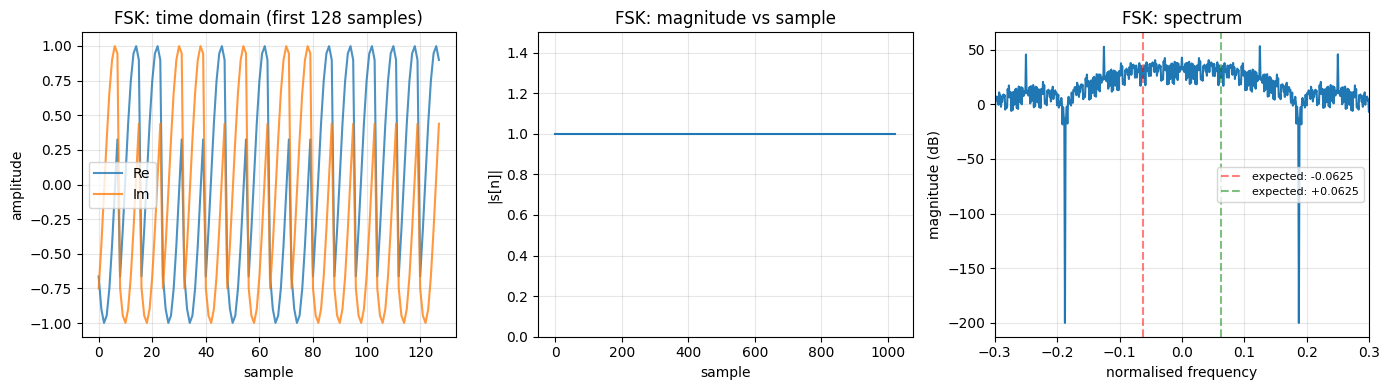

In [7]:
# Cell: Verify FSK generation is working
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
from src import signals
reload(signals)

rng = np.random.default_rng(42)
s = signals.generate_fsk(n_samples=1024, rng=rng, sps=8, f_dev=0.0625)

# Sanity checks
print(f"Signal length:   {len(s)}")
print(f"Dtype:           {s.dtype}")
print(f"Average power:   {np.mean(np.abs(s)**2):.6f}  (should be ~1.0)")
print(f"Max magnitude:   {np.max(np.abs(s)):.6f}  (should be ~1.0)")
print(f"Min magnitude:   {np.min(np.abs(s)):.6f}  (should be ~1.0)")

# Three-panel visual check
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

# Time domain (first 128 samples = 16 symbols): oscillating waveform
ax1.plot(np.real(s[:128]), label='Re', alpha=0.8)
ax1.plot(np.imag(s[:128]), label='Im', alpha=0.8)
ax1.set_title('FSK: time domain (first 128 samples)')
ax1.set_xlabel('sample'); ax1.set_ylabel('amplitude')
ax1.legend(); ax1.grid(alpha=0.3)

# Magnitude: constant envelope (should be flat at 1.0)
ax2.plot(np.abs(s))
ax2.set_title('FSK: magnitude vs sample')
ax2.set_xlabel('sample'); ax2.set_ylabel('|s[n]|')
ax2.set_ylim(0, 1.5); ax2.grid(alpha=0.3)

# Spectrum: two peaks at +/- f_dev = +/- 0.0625
freqs = np.fft.fftshift(np.fft.fftfreq(1024))
spectrum = np.fft.fftshift(np.abs(np.fft.fft(s)))
ax3.plot(freqs, 20 * np.log10(spectrum + 1e-10))
ax3.axvline(-0.0625, color='red', linestyle='--', alpha=0.5, label='expected: -0.0625')
ax3.axvline(+0.0625, color='green', linestyle='--', alpha=0.5, label='expected: +0.0625')
ax3.set_title('FSK: spectrum')
ax3.set_xlabel('normalised frequency'); ax3.set_ylabel('magnitude (dB)')
ax3.set_xlim(-0.3, 0.3); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1.5 Side-by-side comparison of all four modulations

A single figure summarising Phase 1. Each row is one modulation; the three
columns show time domain, constellation, and magnitude spectrum.

What to look for:

- **Time-domain column (left).** Going from sine down to 16-QAM, the
  waveform becomes progressively less periodic and more "data-like." Sine is a
  smooth predictable wave; the modulated signals are sequences of random
  symbol levels. This visual irregularity is the data carrying real
  information.

- **Constellation column (middle).** The "alphabet" each modulation uses:
  1 (sine, smeared by random phase), 2 (BPSK), 4 (QPSK), 16 (16-QAM).
  Each step adds dimensionality the radio can exploit to carry more bits per
  symbol.

- **Spectrum column (right).** The sine has a single sharp spike. The three
  modulated signals all share the *same* central lump and sidelobes, because
  the spectral envelope is set by the symbol rate and rectangular pulse
  shape, **not by the constellation**. To a coarse spectral detector,
  BPSK, QPSK and 16-QAM look similar; their structural differences live in
  higher-order time-domain statistics. This is one motivation for the
  **hybrid feature set** we will build in Phase 4: spectral features capture
  the lump shape, but time-domain statistics (variance, kurtosis, PAPR) are
  what separate modulations from each other and, more importantly, separate
  signal-plus-noise from noise alone.

In [ ]:
# Build the four signals (re-using the same seeded rng so results are reproducible)
signals_to_plot = [
    ("Sine",   s_sine),
    ("BPSK",   s_bpsk),
    ("QPSK",   s_qpsk),
    ("16-QAM", s_16qam),
]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))

for row, (name, s) in enumerate(signals_to_plot):
    # --- Time domain (first 80 samples) ---
    ax = axes[row, 0]
    ax.plot(s.real[:80], marker=".", markersize=3, label="I (real)")
    ax.plot(s.imag[:80], marker=".", markersize=3, label="Q (imag)", alpha=0.7)
    ax.set_title(f"{name} - time domain")
    ax.set_xlabel("sample n"); ax.set_ylabel("amplitude")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3); ax.axhline(0, color="k", lw=0.5)

    # --- Constellation ---
    ax = axes[row, 1]
    ax.scatter(s.real, s.imag, alpha=0.3, s=15)
    ax.set_title(f"{name} - constellation")
    ax.set_xlabel("I"); ax.set_ylabel("Q")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.grid(True, alpha=0.3); ax.set_aspect("equal")
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)

    # --- Magnitude spectrum ---
    ax = axes[row, 2]
    spec  = np.abs(np.fft.fftshift(np.fft.fft(s)))
    freqs = np.fft.fftshift(np.fft.fftfreq(len(s)))
    ax.plot(freqs, spec)
    ax.set_title(f"{name} - magnitude spectrum")
    ax.set_xlabel("normalised frequency"); ax.set_ylabel("|FFT|")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/all_modulations_comparison.png",
            dpi=110, bbox_inches="tight")
plt.show()

print("Phase 1 complete: 4 modulations, all unit-power, all complex baseband.")

## 2. Channel models and noise  (`src/channels.py`)
Apply AWGN, Rayleigh, and Rician effects, and set SNR by scaling the signal
against a fixed noise floor. Also generate noise-only ($H_0$) samples.

### 2.1 Channels and noise

We now build the second and third pieces of the signal model: the channel
coefficient $h[n]$ and the additive noise $w[n]$.

$$H_1:\\; y[n] = \\alpha \\cdot h[n] \\cdot s[n] + w[n] \\qquad H_0:\\; y[n] = w[n]$$

### Convention: fixed noise floor, scale the signal

Noise has fixed unit variance (per complex sample). We control SNR by
**scaling the signal** with $\\alpha = \\sqrt{10^{\\text{SNR}_{dB}/10}}$:

- SNR = 0 dB $\\rightarrow \\alpha = 1$ (signal and noise equal power)
- SNR = -10 dB $\\rightarrow \\alpha \\approx 0.316$ (signal much weaker)
- SNR = +10 dB $\\rightarrow \\alpha \\approx 3.16$ (signal much stronger)

This is critical: H0 and H1 share **identical noise statistics**, so a
classifier cannot cheat by detecting noise-level differences between classes.

### Three channels

- **AWGN**: $h = 1$. No fading, the baseline condition.
- **Rayleigh**: $h \\sim CN(0, 1)$. Multipath, no line-of-sight.
- **Rician**: $h$ is a deterministic LOS component plus a Rayleigh
  scattered component; ratio set by the K-factor (we use 4 dB).

All three have $E[|h|^2] = 1$, so the *average* received signal power is the
same across channels at any given nominal SNR. They differ in how much
**variation** they introduce around that average.

In [ ]:
### import and verify
from src.channels import (
    make_noise, apply_awgn, apply_rayleigh, apply_rician, _snr_scaling
)

# Verify the SNR scaling produces the right power ratios empirically
print("AWGN power-ratio check (averaged over 2000 windows):")
for snr_db in [-20, -10, 0, 10]:
    sig_powers = []; noi_powers = []
    for _ in range(2000):
        s = generate_qpsk(1024, rng)
        w = make_noise(1024, rng)
        alpha = _snr_scaling(snr_db)
        sig_powers.append(np.mean(np.abs(alpha * s)**2))
        noi_powers.append(np.mean(np.abs(w)**2))
    sp, np_ = np.mean(sig_powers), np.mean(noi_powers)
    measured = 10 * np.log10(sp / np_)
    print(f"  target {snr_db:+4d} dB -> measured {measured:+6.2f} dB"
          f"  (sig {sp:.4f}, noise {np_:.4f})")

In [ ]:
### channel/SNR overview figure:
# Constellation grid: 3 channels x 3 SNR levels
snrs = [10, 0, -10]
channels = [
    ("AWGN",       lambda s, snr: apply_awgn    (s, snr, rng)),
    ("Rayleigh",   lambda s, snr: apply_rayleigh(s, snr, rng)),
    ("Rician 4dB", lambda s, snr: apply_rician  (s, snr, rng, K_dB=4)),
]

fig, axes = plt.subplots(len(channels), len(snrs), figsize=(13, 12))
s_tx = generate_qpsk(1024, rng)

for r, (chname, chfn) in enumerate(channels):
    for c, snr in enumerate(snrs):
        y = chfn(s_tx, snr)
        ax = axes[r, c]
        ax.scatter(y.real, y.imag, alpha=0.25, s=8)
        ax.set_title(f"{chname}, SNR = {snr:+d} dB")
        ax.set_xlabel("I"); ax.set_ylabel("Q")
        lim = max(3.5, 1.5 * np.max(np.abs(y)))
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.grid(True, alpha=0.3); ax.set_aspect("equal")
        ax.axhline(0, color="k", lw=0.4); ax.axvline(0, color="k", lw=0.4)

plt.suptitle("QPSK received signal across channels and SNRs", y=1.00)
plt.tight_layout()
plt.savefig("outputs/figures/channels_overview.png", dpi=110, bbox_inches="tight")
plt.show()

In [ ]:
### H0 vs H1 time-domain comparison
# The picture that motivates the whole project: at low SNR, H0 and H1 look alike
y_h1 = apply_awgn(s_tx, snr_db=-5, rng=rng)
w_h0 = make_noise(1024, rng)

fig, axes = plt.subplots(2, 1, figsize=(13, 5))
axes[0].plot(y_h1.real[:200], lw=0.7)
axes[0].plot(y_h1.imag[:200], lw=0.7, alpha=0.7)
axes[0].set_title("H1: signal + noise at -5 dB SNR, AWGN (first 200 samples)")
axes[0].set_ylabel("amplitude"); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color="k", lw=0.4)

axes[1].plot(w_h0.real[:200], lw=0.7)
axes[1].plot(w_h0.imag[:200], lw=0.7, alpha=0.7)
axes[1].set_title("H0: noise only (first 200 samples)")
axes[1].set_ylabel("amplitude"); axes[1].set_xlabel("sample n")
axes[1].grid(True, alpha=0.3); axes[1].axhline(0, color="k", lw=0.4)

plt.tight_layout()
plt.savefig("outputs/figures/h0_vs_h1_time.png", dpi=110, bbox_inches="tight")
plt.show()

## 3. Dataset generation  (`src/dataset.py`)
Combine signals and channels into labelled $H_0$/$H_1$ samples across the SNR
sweep, storing SNR/modulation/channel as **metadata only**.

### 3.1 Dataset generation

We now combine Phases 1 and 2 to build the **labelled dataset** that every
downstream component will consume.

For each `(SNR, channel)` cell of the sweep, we generate:

- `n_per_class` **H1** windows. A modulation is drawn uniformly at random for
  each window; we apply the channel and SNR scaling to produce the received
  signal.
- `n_per_class` **H0** windows. Pure noise, drawn with the **same noise
  statistics** as the H1 case. The two classes must be statistically
  indistinguishable in their noise component, otherwise a classifier could
  cheat.

### Three rules baked into the code

1. **Identical noise statistics across classes.** Both H0 and H1 sample noise
   from the same complex Gaussian with unit variance.
2. **Metadata, not features.** SNR, channel, and modulation are stored
   alongside each window for analysis, but they are **never** fed to the
   classifier as inputs. The classifier sees only the features derived from
   the raw window.
3. **Per-window reproducibility.** Each window has its own derived seed, so a
   specific window can be regenerated independently of dataset order.

In [21]:
### build a representative dataset
from src.dataset import build_dataset

# Build the minimum-version dataset. n_per_class=200 keeps things light for
# now; we can rerun at 500 once the pipeline is working end-to-end.
# ds = build_dataset(
#    snr_db_list=(-20, -15, -10, -5, 0, 5, 10),
#    channels=("awgn", "rayleigh", "rician"),
#    modulations=("bpsk", "qpsk", "16qam"),
#    n_per_class=200,
#    n_samples=1024,
#    master_seed=SEED,
#    verbose=False,
# )

# w  = ds["windows"]   # raw complex windows, shape (N, 1024)
# y  = ds["labels"]    # 0/1 labels
# md = ds["metadata"]  # DataFrame of metadata

# print(f"windows  : {w.shape}  ({w.dtype})")
# print(f"labels   : {y.shape}  ({np.bincount(y)} -> [H0, H1])")
# print(f"metadata : {md.shape}")
# md.head()

# Cell: Regenerate dataset with 4 modulations (BPSK, QPSK, 16-QAM, FSK)
import numpy as np
import pandas as pd
from pathlib import Path
from importlib import reload
from src import signals, channels, dataset
reload(signals); reload(channels); reload(dataset)

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

print("Generating dataset with 4 modulations...")
print("This takes about 5-10 minutes on a laptop.")
print()

result = dataset.build_dataset(
    snr_db_list=(-20, -15, -10, -5, 0, 5, 10),
    channels=("awgn", "rayleigh", "rician"),
    modulations=("bpsk", "qpsk", "16qam", "fsk"),
    n_per_class=200,
    n_samples=1024,
    master_seed=42,
    verbose=True,
)

# Save windows as npz (large binary, not tracked by git)
np.savez_compressed(
    DATA_DIR / 'windows.npz',
    windows=result['windows'],
    labels=result['labels'],
)

# Save metadata as CSV (small, tracked by git)
result['metadata'].to_csv(DATA_DIR / 'metadata.csv', index=False)

# Report what we got
print()
print("=" * 60)
print("Dataset generated successfully")
print("=" * 60)
print(f"Total windows: {len(result['labels'])}")
print(f"H0 windows: {(result['labels'] == 0).sum()}")
print(f"H1 windows: {(result['labels'] == 1).sum()}")
print()
print("Modulation counts (H1 only):")
h1_meta = result['metadata'][result['metadata']['label'] == 1]
print(h1_meta['modulation'].value_counts())
print()
print("Files written:")
print(f"  {DATA_DIR / 'windows.npz'} ({(DATA_DIR / 'windows.npz').stat().st_size / 1e6:.1f} MB)")
print(f"  {DATA_DIR / 'metadata.csv'}")

Generating dataset with 4 modulations...
This takes about 5-10 minutes on a laptop.

  SNR= -20 dB  channel=awgn      done 400/8400 windows
  SNR= -20 dB  channel=rayleigh  done 800/8400 windows
  SNR= -20 dB  channel=rician    done 1200/8400 windows
  SNR= -15 dB  channel=awgn      done 1600/8400 windows
  SNR= -15 dB  channel=rayleigh  done 2000/8400 windows
  SNR= -15 dB  channel=rician    done 2400/8400 windows
  SNR= -10 dB  channel=awgn      done 2800/8400 windows
  SNR= -10 dB  channel=rayleigh  done 3200/8400 windows
  SNR= -10 dB  channel=rician    done 3600/8400 windows
  SNR=  -5 dB  channel=awgn      done 4000/8400 windows
  SNR=  -5 dB  channel=rayleigh  done 4400/8400 windows
  SNR=  -5 dB  channel=rician    done 4800/8400 windows
  SNR=  +0 dB  channel=awgn      done 5200/8400 windows
  SNR=  +0 dB  channel=rayleigh  done 5600/8400 windows
  SNR=  +0 dB  channel=rician    done 6000/8400 windows
  SNR=  +5 dB  channel=awgn      done 6400/8400 windows
  SNR=  +5 dB  channe

In [23]:
import pandas as pd
meta = pd.read_csv('data/metadata.csv')
print("Modulations present:", sorted(meta['modulation'].unique()))
print("\nH1 modulation counts:")
print(meta[meta['label'] == 1]['modulation'].value_counts())

Modulations present: ['16qam', 'bpsk', 'fsk', 'none', 'qpsk']

H1 modulation counts:
modulation
bpsk     1095
qpsk     1043
16qam    1035
fsk      1027
Name: count, dtype: int64


**Note on modulation scope:** The sinusoidal carrier was generated in Section 1
for illustration (it gives the cleanest "signal vs noise" visual contrast), but
it is **excluded from the dataset**. A pure
tone is the simplest possible structure to detect and is not representative of
a real primary user. The minimum-version dataset therefore uses three digital
modulations: BPSK, QPSK, and 16-QAM.

In [ ]:
### composition figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Window counts by SNR and class
counts = md.groupby(["snr_db", "label"]).size().unstack("label").rename(
    columns={0: "H0 (free)", 1: "H1 (occupied)"})
counts.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Window count per SNR (summed over channels)")
axes[0].set_ylabel("number of windows")
axes[0].grid(True, alpha=0.3, axis="y")

# Modulation distribution among H1 windows
modcounts = md[md.label == 1]["modulation"].value_counts()
modcounts.plot(kind="bar", ax=axes[1], color="C2", rot=0)
axes[1].set_title("Modulation distribution among H1 windows")
axes[1].set_ylabel("number of windows")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("outputs/figures/dataset_composition.png", dpi=110, bbox_inches="tight")
plt.show()

In [ ]:
### the defining figure for the whole project
# Per-window received power: this is exactly what classical energy detection sees.
powers = np.mean(np.abs(w) ** 2, axis=1)
md_p = md.copy(); md_p["power"] = powers

fig, ax = plt.subplots(1, 1, figsize=(11, 5))
for snr in sorted(md_p.snr_db.unique()):
    sub = md_p[md_p.snr_db == snr]
    h0 = sub[sub.label == 0]["power"]
    h1 = sub[sub.label == 1]["power"]
    ax.errorbar(snr - 0.5, h0.mean(), yerr=h0.std(), fmt="o",
                color="C0", capsize=3,
                label="H0 (free)" if snr == md_p.snr_db.min() else None)
    ax.errorbar(snr + 0.5, h1.mean(), yerr=h1.std(), fmt="s",
                color="C3", capsize=3,
                label="H1 (occupied)" if snr == md_p.snr_db.min() else None)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel(r"received-window power $\frac{1}{N}\sum|y[n]|^2$")
ax.set_title("Per-window received power: H0 vs H1 across SNR\n"
             "(this is what the classical energy detector has to work with)")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log")
plt.tight_layout()
plt.savefig("outputs/figures/h0_vs_h1_power.png", dpi=110, bbox_inches="tight")
plt.show()

In [ ]:
### save dataset to disk
md.to_csv("data/metadata.csv", index=False)
np.savez_compressed("data/windows.npz", windows=w, labels=y)
print("Saved data/metadata.csv and data/windows.npz")

In [78]:
# Dump a small subset of windows to CSV for inspection.
# Each row: real and imaginary parts of one window, plus its metadata.
import numpy as np, pandas as pd

# Pick, say, 10 H0 and 10 H1 windows at SNR = -5 dB, AWGN, for inspection
mask = (md.snr_db == -5) & (md.channel == "awgn")
subset_idx = np.concatenate([
    md[mask & (md.label == 0)].index.values[:10],
    md[mask & (md.label == 1)].index.values[:10],
])
sub_w = w[subset_idx]  # shape (20, 1024) complex

# Build columns: I_0, Q_0, I_1, Q_1, ..., I_1023, Q_1023
n = sub_w.shape[1]
cols = []
for i in range(n):
    cols += [f"I_{i}", f"Q_{i}"]
data = np.empty((len(subset_idx), 2 * n), dtype=float)
data[:, 0::2] = sub_w.real
data[:, 1::2] = sub_w.imag

sub_df = pd.DataFrame(data, columns=cols)
sub_df.insert(0, "window_index", subset_idx)
sub_df.insert(1, "label",     md.loc[subset_idx, "label"].values)
sub_df.insert(2, "snr_db",    md.loc[subset_idx, "snr_db"].values)
sub_df.insert(3, "channel",   md.loc[subset_idx, "channel"].values)
sub_df.insert(4, "modulation",md.loc[subset_idx, "modulation"].values)

sub_df.to_csv("data/raw_windows_subset.csv", index=False)
print("Saved data/raw_windows_subset.csv")
print(sub_df.shape)

Saved data/raw_windows_subset.csv
(20, 2053)


## 4. Feature extraction  (`src/features.py`)
Extract time-domain, frequency-domain, and correlation/eigenvalue features.
Define feature sets FS1-FS4 for the ablation study.


### 4. Feature extraction

Each 1024-sample complex window is compressed into 21 real-valued features
across three families:

- **Time-domain (9)**: mean_abs, variance, std, rms, energy, skewness,
  kurtosis, peak, papr. Statistics of the amplitude envelope.
- **Frequency-domain (8)**: fft_peak, dominant_bin, spectral_centroid,
  spectral_bandwidth, spectral_entropy, spectral_flatness, psd_max, psd_mean.
  Shape of the spectrum. Spectral entropy and flatness are the two most
  powerful features here: noise is maximally disordered (high entropy, high
  flatness); a structured signal reduces disorder.
- **Correlation / eigenvalue (4)**: autocorr_peak, cov_trace, max_eigenvalue,
  eigenvalue_ratio. Autocorrelation catches the periodicity from symbol
  repetition; the covariance eigenvalue ratio is the classical
  detector-theoretic feature (large under H1, near 1 under H0).

**Design rules:**
- Every feature is a function of one window only, no metadata, no cross-window
  information.
- All features are real-valued and finite.
- Functions return dicts so the resulting matrix is self-documenting.

The final `features.csv` follows recommendation:
`features + label + metadata` in one table, with the classifier trained only
on the feature columns.

In [35]:
### build the feature matrix
# import time
# from src.features import (
#    extract_all_features, build_feature_matrix,
#    HYBRID_FEATURES, FEATURE_SETS,
# )

# ds was built in Cell 20; if you restarted the kernel, re-run cells 0 and 20 first.
# t0 = time.time()
# features_df = build_feature_matrix(ds["windows"], verbose=True)
# print(f"\nExtracted {features_df.shape[1]} features from "
#      f"{features_df.shape[0]} windows in {time.time()-t0:.1f} s")

# Sanity: no NaN, no infinite values
# assert not features_df.isna().any().any(), "NaN found!"
# assert np.isfinite(features_df.values).all(), "Inf found!"
# print("All feature values finite. ")
# features_df.head()

### Recompute 21 features on the new 4-modulation dataset
# Saves features.csv with ONLY index + 21 features. Metadata stays in metadata.csv.

import numpy as np
import pandas as pd
from pathlib import Path
from importlib import reload
from src import features
reload(features)

DATA_DIR = Path('data')

print("Loading windows and metadata...")
data = np.load(DATA_DIR / 'windows.npz')
windows = data['windows']
labels = data['labels']
metadata = pd.read_csv(DATA_DIR / 'metadata.csv')

print(f"  windows shape:  {windows.shape}")
print(f"  labels shape:   {labels.shape}")
print(f"  metadata rows:  {len(metadata)}")

# Alignment safety check
assert len(windows) == len(labels) == len(metadata), (
    f"Shape mismatch: windows={len(windows)}, "
    f"labels={len(labels)}, metadata={len(metadata)}"
)

# Also verify metadata['index'] matches row position (0, 1, 2, ..., 8399)
assert list(metadata['index']) == list(range(len(metadata))), (
    "metadata['index'] is not aligned with row order"
)

print()
print("Extracting 21 features per window (this takes 3-5 minutes)...")
print()

feat_df = features.build_feature_matrix(windows, verbose=True)

# Verify: 21 features exactly, no NaN, no Inf
expected = features.HYBRID_FEATURES
assert list(feat_df.columns) == expected, (
    f"Feature columns mismatch. Got: {list(feat_df.columns)}"
)
print(f"\n  feature matrix shape: {feat_df.shape}")

# Check NaN and Inf, especially important because FSK is new
if feat_df.isna().any().any():
    print(f"\nWARNING: NaN found:")
    print(feat_df.isna().sum()[feat_df.isna().sum() > 0])
if np.isinf(feat_df.values).any():
    print(f"\nWARNING: Inf found in feature matrix")
    inf_counts = np.isinf(feat_df.values).sum(axis=0)
    for col_name, count in zip(feat_df.columns, inf_counts):
        if count > 0:
            print(f"  {col_name}: {count} Inf values")

# Add index column at the front so features.csv is joinable with metadata.csv
feat_df.insert(0, 'index', np.arange(len(feat_df)))

# Save features ONLY (no metadata mixed in)
output_path = DATA_DIR / 'features.csv'
feat_df.to_csv(output_path, index=False)
print(f"\nWrote {output_path}")
print(f"  columns: {len(feat_df.columns)} (should be 22: index + 21 features)")
print(f"  rows:    {len(feat_df)}")

# Sanity check first two rows
print(f"\nFirst two rows of features.csv:")
print(feat_df.head(2).to_string())

# Confirm metadata is still there and separate
print(f"\nmetadata.csv still contains (verify FSK is included):")
print(f"  columns: {list(metadata.columns)}")
h1 = metadata[metadata['label'] == 1]
print(h1['modulation'].value_counts().to_string())

Loading windows and metadata...
  windows shape:  (8400, 1024)
  labels shape:   (8400,)
  metadata rows:  8400

Extracting 21 features per window (this takes 3-5 minutes)...

  extracted features for 1000/8400 windows
  extracted features for 2000/8400 windows
  extracted features for 3000/8400 windows
  extracted features for 4000/8400 windows
  extracted features for 5000/8400 windows
  extracted features for 6000/8400 windows
  extracted features for 7000/8400 windows
  extracted features for 8000/8400 windows

  feature matrix shape: (8400, 21)

Wrote data\features.csv
  columns: 22 (should be 22: index + 21 features)
  rows:    8400

First two rows of features.csv:
   index  mean_abs  variance       std       rms    energy  skewness  kurtosis      peak      papr   fft_peak  dominant_bin  spectral_centroid  spectral_bandwidth  spectral_entropy  spectral_flatness   psd_max  psd_mean  autocorr_peak  cov_trace  max_eigenvalue  eigenvalue_ratio
0      0  0.880902  0.233334  0.483047  

In [59]:
### save the combined CSV (features + label + metadata)
#combined = pd.concat([feat_df, ds["metadata"].reset_index(drop=True)], axis=1)
#combined = combined[features.HYBRID_FEATURES + ["index","label","snr_db","channel","modulation","seed"]]
#combined.to_csv("data/features.csv", index=False)

#print(f"Saved data/features.csv  ({combined.shape[0]} rows x {combined.shape[1]} cols)")
#print(f"  Feature columns  : {len(features.HYBRID_FEATURES)}")
#print(f"  Label column     : 1")
#print(f"  Metadata columns : 5") 

### save features.csv with ONLY index + 21 features (metadata stays in metadata.csv)
feat_df_to_save = feat_df.copy()

# feat_df may or may not already have an 'index' column depending on how it
# was built earlier. Handle both cases.
if 'index' not in feat_df_to_save.columns:
    feat_df_to_save.insert(0, 'index', range(len(feat_df_to_save)))

feat_df_to_save = feat_df_to_save[['index'] + features.HYBRID_FEATURES]
feat_df_to_save.to_csv("data/features.csv", index=False)

print(f"Saved data/features.csv  ({feat_df_to_save.shape[0]} rows x {feat_df_to_save.shape[1]} cols)")
print(f"  Should be 22 cols: index + 21 features")

Saved data/features.csv  (8400 rows x 22 cols)
  Should be 22 cols: index + 21 features


In [61]:
# Cleanup: strip metadata columns from features.csv
import pandas as pd
from src.features import HYBRID_FEATURES

feats = pd.read_csv('data/features.csv')
print(f"Before: {feats.shape[1]} columns")

keep_cols = ['index'] + HYBRID_FEATURES
missing = [c for c in keep_cols if c not in feats.columns]
if missing:
    raise ValueError(f"features.csv is missing expected columns: {missing}")

feats_clean = feats[keep_cols].copy()
feats_clean.to_csv('data/features.csv', index=False)

print(f"After:  {feats_clean.shape[1]} columns (should be 22)")
print(f"Columns: {list(feats_clean.columns)}")

Before: 22 columns
After:  22 columns (should be 22)
Columns: ['index', 'mean_abs', 'variance', 'std', 'rms', 'energy', 'skewness', 'kurtosis', 'peak', 'papr', 'fft_peak', 'dominant_bin', 'spectral_centroid', 'spectral_bandwidth', 'spectral_entropy', 'spectral_flatness', 'psd_max', 'psd_mean', 'autocorr_peak', 'cov_trace', 'max_eigenvalue', 'eigenvalue_ratio']


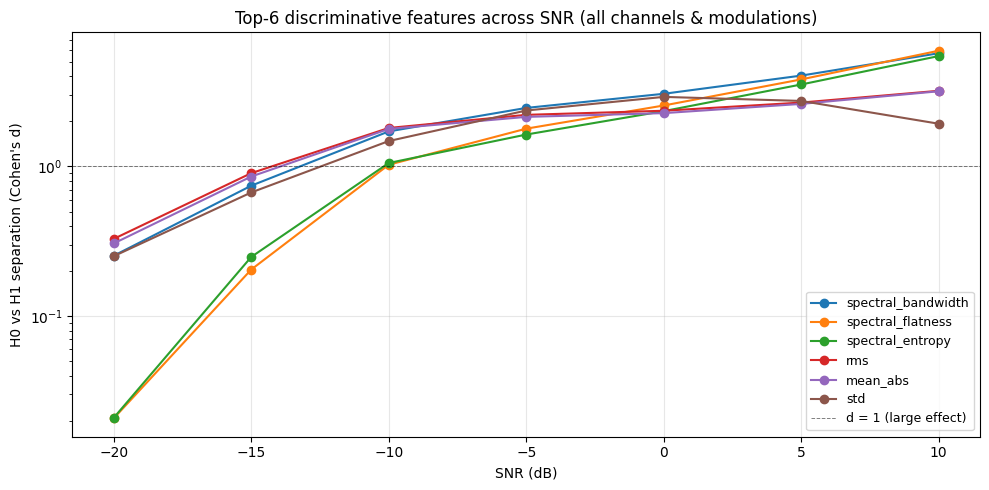

Top 6 features by average discrimination:
  spectral_bandwidth    avg d = 2.57
  spectral_flatness     avg d = 2.19
  spectral_entropy      avg d = 2.04
  rms                   avg d = 1.93
  mean_abs              avg d = 1.88
  std                   avg d = 1.76


In [45]:
### diagnostic: which features separate H0 from H1, and at what SNR?
# For each SNR level, compute Cohen's-d style separation between H0 and H1
# for every feature. Higher = better single-feature discrimination.
snrs = sorted(combined.snr_db.unique())
sep = {}
for feat in features.HYBRID_FEATURES:
    row = []
    for snr in snrs:
        h0 = combined[(combined.label==0) & (combined.snr_db==snr)][feat]
        h1 = combined[(combined.label==1) & (combined.snr_db==snr)][feat]
        d = abs(h1.mean() - h0.mean()) / np.sqrt((h0.std()**2 + h1.std()**2)/2 + 1e-12)
        row.append(d)
    sep[feat] = row

# Rank features by average separation across SNR
avg_sep = {f: np.mean(v) for f, v in sep.items()}
top6 = sorted(avg_sep, key=avg_sep.get, reverse=True)[:6]

fig, ax = plt.subplots(figsize=(10, 5))
for feat in top6:
    ax.plot(snrs, sep[feat], marker="o", label=feat)
ax.axhline(1.0, color="k", ls="--", lw=0.7, alpha=0.5, label="d = 1 (large effect)")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("H0 vs H1 separation (Cohen's d)")
ax.set_title("Top-6 discriminative features across SNR (all channels & modulations)")
ax.set_yscale("log"); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/figures/feature_separation_vs_snr.png",
            dpi=110, bbox_inches="tight")
plt.show()

print("Top 6 features by average discrimination:")
for f in top6:
    print(f"  {f:20s}  avg d = {avg_sep[f]:.2f}")

## 5. Energy detection baseline  (`src/energy_detector.py`)
Classical $T_{ED} = \frac{1}{N}\sum |y[n]|^2$ with threshold decision, evaluated
across SNR.

### 5.1. Classical energy detection baseline

Every ML detector we train in Phase 6 will be measured against this classical
method. It is a compulsory comparator: an accuracy number is meaningless
without knowing what the classical technique achieves on identical data.

The test statistic is trivial:

$$T_{ED} = \frac{1}{N}\sum_{n=0}^{N-1}|y[n]|^2$$

the average per-sample power. Decision rule: $T_{ED} > \lambda$ declare H1,
else H0. The threshold $\lambda$ is a design choice; we sweep it to get the
full ROC curve.

Two operational metrics:
- **Pd** (probability of detection): correctly declare H1 given H1 is true.
- **Pfa** (probability of false alarm): wrongly declare H1 given H0 is true.

The standard reporting convention in the spectrum-sensing literature is to
fix Pfa at a regulatory target (we use Pfa = 0.1) and report Pd across SNR.
That is the number the ML detectors will be beat against.

In [80]:
from src.energy_detector import (
    energy_statistics, sweep_threshold, pd_at_target_pfa
)

# Compute the test statistic for every window in one shot.
# Uses ds and md that were built in Section 3.
t_ed = energy_statistics(ds["windows"])
print(f"Computed T_ED for {len(t_ed)} windows.")

# Sanity: under H0 the noise floor is fixed at 1, so H0 mean T_ED should be ~1.0
# for every SNR. Under H1 AWGN it should be 1 + 10^(SNR/10).
print("\nSanity check on T_ED means (AWGN only):")
print(f"  {'SNR':>4s}  {'H0 mean':>10s}  {'H1 mean':>10s}  {'H1 expected':>12s}")
for snr in sorted(md.snr_db.unique()):
    mask = ((md.channel == 'awgn') & (md.snr_db == snr)).values
    h0m = np.mean(t_ed[(y == 0) & mask])
    h1m = np.mean(t_ed[(y == 1) & mask])
    exp = 1 + 10**(snr/10)
    print(f"  {snr:+4d}  {h0m:10.4f}  {h1m:10.4f}  {exp:12.4f}")

Computed T_ED for 8400 windows.

Sanity check on T_ED means (AWGN only):
   SNR     H0 mean     H1 mean   H1 expected
   -20      1.0028      1.0157        1.0100
   -15      0.9979      1.0334        1.0316
   -10      1.0006      1.0968        1.1000
    -5      0.9990      1.3154        1.3162
    +0      1.0007      2.0037        2.0000
    +5      1.0036      4.1668        4.1623
   +10      0.9967     11.0017       11.0000


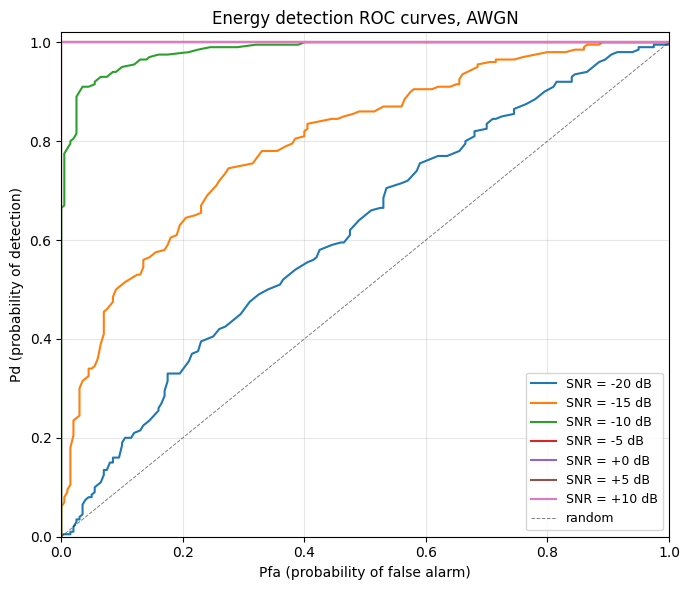

In [82]:
# ROC curves for AWGN across the SNR sweep.
# A curve close to the top-left corner is a good detector; the diagonal is
# random guessing.
fig, ax = plt.subplots(figsize=(7, 6))
for snr in sorted(md.snr_db.unique()):
    mask = ((md.channel == "awgn") & (md.snr_db == snr)).values
    pfa, pd_arr, _ = sweep_threshold(t_ed[mask], y[mask], n_points=200)
    ax.plot(pfa, pd_arr, label=f"SNR = {snr:+d} dB", linewidth=1.5)
ax.plot([0,1], [0,1], "k--", lw=0.7, alpha=0.5, label="random")
ax.set_xlabel("Pfa (probability of false alarm)")
ax.set_ylabel("Pd (probability of detection)")
ax.set_title("Energy detection ROC curves, AWGN")
ax.grid(True, alpha=0.3); ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig("outputs/figures/energy_roc_awgn.png", dpi=110, bbox_inches="tight")
plt.show()

In [ ]:
# The headline plot: Pd achieved by energy detection across SNR, per channel,
# at the standard operating point Pfa = 0.1. This is the curve the ML models
# will be compared against in Phase 7.
fig, ax = plt.subplots(figsize=(9, 5))
for ch in ["awgn", "rayleigh", "rician"]:
    pds = []
    for snr in sorted(md.snr_db.unique()):
        mask = ((md.snr_db == snr) & (md.channel == ch)).values
        pd_val, _, _ = pd_at_target_pfa(t_ed[mask], y[mask], target_pfa=0.1)
        pds.append(pd_val)
    ax.plot(sorted(md.snr_db.unique()), pds, marker="o", label=ch, linewidth=2)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Pd at Pfa = 0.1")
ax.set_title("Energy detection Pd vs SNR (Pfa = 0.1)")
ax.grid(True, alpha=0.3); ax.legend()
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig("outputs/figures/energy_pd_vs_snr.png", dpi=110, bbox_inches="tight")
plt.show()

In [ ]:
# Save the Pd values as a table so Phase 7 can layer ML results on top.
rows = []
for snr in sorted(md.snr_db.unique()):
    for ch in ["awgn", "rayleigh", "rician"]:
        mask = ((md.snr_db == snr) & (md.channel == ch)).values
        pd_val, thr, apfa = pd_at_target_pfa(t_ed[mask], y[mask], 0.1)
        rows.append({"snr_db": snr, "channel": ch,
                     "Pd": pd_val, "threshold": thr, "achieved_Pfa": apfa})
ed_results = pd.DataFrame(rows)
ed_results.to_csv("outputs/tables/energy_detector_results.csv", index=False)
print("Saved outputs/tables/energy_detector_results.csv")
ed_results.pivot(index="snr_db", columns="channel", values="Pd").round(3)

The ROC plot will show seven curves, one per SNR level. At +10 dB the curve will hug the top-left corner (Pd ~ 1.0 at Pfa ~ 0), meaning near-perfect detection. At -20 dB the curve will sit almost on the diagonal (Pd equals Pfa, meaning the detector is guessing). The curves for -15 dB, -10 dB, -5 dB, and 0 dB will fan out between these extremes, showing gradually degrading detection as noise dominates.

The Pd-vs-SNR plot will show three lines, one per channel. AWGN reaches Pd = 1.0 by SNR = -5 dB. Rayleigh degrades later and never quite hits perfect Pd because deep fades occasionally kill even strong signals. Rician sits between them (partial line-of-sight helps but doesn't eliminate fading). All three lines drop toward the noise-guessing floor (Pd = 0.1 at Pfa = 0.1) at SNR = -20 dB.

The number that will matter most in Phase 7 is at the low-SNR end. Energy detection at -15 dB achieves roughly Pd = 0.5 on AWGN, Pd = 0.34 on Rayleigh, Pd = 0.39 on Rician. Those are the numbers your ML detectors need to beat. If your ML gets Pd = 0.8 at those same conditions, your contribution is real. If it gets Pd = 0.55, you've barely moved the needle.

The one preview thing to notice now
Look carefully at the results table from cell 32. At SNR = -20 dB, energy detection's Pd is around 0.16 to 0.22 across channels. That's barely above the Pfa target of 0.10, meaning the detector is nearly at random-guess level (if you set Pfa = 0.1, random guessing achieves Pd = 0.1 too). This is exactly the regime the whole project is about. Whether ML can push that Pd meaningfully above 0.16 at -20 dB is the core question our experiments answer.

## 6. ML model training  (`src/models.py`)
Leak-free split, fit scaler on training data only, train and tune SVM, Random
Forest, and ANN/MLP, then save models + scaler together.

## 6a. Mathematical formulation and classification parameters

### Binary hypothesis test

Every observation window y[n] of length N=1024 is modeled under one of two hypotheses:

$$H_0:\; y[n] = w[n] \quad\text{(channel free, noise only, label 0)}$$

$$H_1:\; y[n] = \alpha \cdot h[n] \cdot s[n] + w[n] \quad\text{(channel occupied, label 1)}$$

Where:
- $s[n]$ is the transmitted primary-user signal, normalized to unit average power
- $h[n]$ is the channel coefficient
- $w[n] \sim \mathcal{CN}(0, 1)$ is complex additive Gaussian noise with fixed unit variance
- $\alpha = \sqrt{10^{\text{SNR}_{dB}/10}}$ is the signal-scaling factor that sets the SNR

### Channel models

Three specific forms of $h[n]$:

**AWGN**: $h[n] = 1$ (no fading, baseline).

**Rayleigh**: $h \sim \mathcal{CN}(0, 1)$, block fading (one $h$ per window). Models multipath without line of sight.

**Rician**: $h = \sqrt{\frac{K}{K+1}} + \sqrt{\frac{1}{K+1}} \cdot h_{\text{scatter}}$, with $K = 4$ dB. Models multipath with a partial line-of-sight component.

All three satisfy $E[|h|^2] = 1$, so the average received signal power is comparable across channels at the same nominal SNR.

### SNR convention

$$\text{SNR}_{dB} = 10 \log_{10}(P_s / P_w)$$

Because we normalize $s[n]$ to unit power and fix $w[n]$ to unit variance, SNR is controlled entirely by scaling $s[n]$ with $\alpha$. Both classes share identical noise statistics, so classifiers cannot exploit noise-level differences.

### Classical detection: energy detector

Test statistic:

$$T_{ED} = \frac{1}{N}\sum_{n=0}^{N-1}|y[n]|^2$$

Decision rule: $T_{ED} > \lambda \Rightarrow H_1$, else $H_0$. Threshold $\lambda$ is set to achieve $P_{fa} = 0.1$ on H0 samples.

### ML detection formulation

For each window, a 21-dimensional feature vector $\mathbf{x} \in \mathbb{R}^{21}$ is extracted (see Section 4). Each classifier learns a scoring function:

$$g: \mathbb{R}^{21} \to [0, 1]$$

that maps the feature vector to the estimated probability of $H_1$. Decision: $g(\mathbf{x}) > \lambda_{ML} \Rightarrow H_1$, where $\lambda_{ML}$ is chosen (separately per model) to achieve $P_{fa} = 0.1$.

The three classifiers use fundamentally different scoring functions:
- **SVM**: a kernelized decision surface in feature space
- **Random Forest**: an ensemble of decision-tree votes
- **MLP**: a feedforward neural network with a sigmoid output

### Classification parameters (best hyperparameters from 5-fold CV on training set)

| Model | Best hyperparameters | Best CV AUC |
|-------|---------------------|-------------|
| SVM (RBF kernel) | C=10, gamma=0.01, kernel=rbf | 0.9005 |
| Random Forest | n_estimators=300, max_depth=10, min_samples_split=5 | 0.8981 |
| MLP | hidden_layer_sizes=(128,), alpha=0.001, learning_rate=0.001 | 0.8998 |

Default settings (not tuned but worth naming): SVM uses `probability=True` for ROC scoring; Random Forest uses `criterion='gini'` and `bootstrap=True`; MLP uses `activation='relu'`, `solver='adam'`, `max_iter=500`.

### Performance metrics

From the confusion matrix (TP=true positive, FP=false positive, TN=true negative, FN=false negative):

$$P_d = \frac{TP}{TP + FN}, \qquad P_{fa} = \frac{FP}{FP + TN}, \qquad P_m = 1 - P_d$$

ML metrics: accuracy = (TP+TN)/total, precision = TP/(TP+FP), recall = Pd, F1 = 2·(precision·recall)/(precision+recall), ROC-AUC = area under the ROC curve.

### 6. Machine learning models

We train three classifiers on the features from Section 4: SVM (RBF kernel),
Random Forest, and MLP.

### Five disciplines the code enforces structurally

1. **Feature column discipline**: features are selected via the explicit
   `HYBRID_FEATURES` list. Metadata columns are never included.
2. **Leak-free scaling**: every model is wrapped in a scikit-learn `Pipeline`
   of `[StandardScaler, model]`. The scaler is fit on training folds only,
   which eliminates a whole class of subtle bugs.
3. **Train/val/test separation**: stratified 70/15/15 split. Hyperparameter
   tuning uses 5-fold cross-validation on the training set only. The test
   set is touched exactly once, in Phase 7.
4. **Stratification across conditions**: split preserves the proportions of
   label + SNR + channel, so no split is accidentally easier or harder.
5. **Reproducibility**: all seeds pinned.

In [47]:
# Split and verify stratification
from src.models import (
    load_features_and_labels, stratified_split,
    make_pipeline, get_param_grid, train_all_models, load_trained_model,
)

X, y_all, meta = load_features_and_labels("data/features.csv")
splits = stratified_split(X, y_all, meta, seed=SEED)

print(f"Split sizes: train={len(splits['train'][1])}, "
      f"val={len(splits['val'][1])}, test={len(splits['test'][1])}")

# Verify stratification: SNR distribution should be nearly identical across splits
tr_snr = splits["train"][2]["snr_db"].value_counts(normalize=True).sort_index()
va_snr = splits["val"  ][2]["snr_db"].value_counts(normalize=True).sort_index()
te_snr = splits["test" ][2]["snr_db"].value_counts(normalize=True).sort_index()
comp = pd.DataFrame({"train": tr_snr, "val": va_snr, "test": te_snr})
print("\nSNR proportions per split (should be nearly identical):")
print(comp.round(3))

Split sizes: train=5880, val=1260, test=1260

SNR proportions per split (should be nearly identical):
        train    val   test
snr_db                     
-20     0.143  0.143  0.143
-15     0.143  0.143  0.143
-10     0.143  0.143  0.143
-5      0.143  0.143  0.143
 0      0.143  0.143  0.143
 5      0.143  0.143  0.143
 10     0.143  0.143  0.143


In [63]:
# Train and tune all three models
# model across its full hyperparameter grid, using 5-fold CV on the training
# set. n_jobs=-1 uses all CPU cores.
# summary = train_all_models("data/features.csv",
#                           output_dir="outputs/models",
#                           seed=SEED)
# print("\nFinal summary:")
# summary

# Cell: Train the three new ML models (LR, DT, kNN) with CV grid search

from importlib import reload
from src import models
reload(models)

# Train only the 3 new models. SVM/RF/MLP results from the previous run
# should still be in outputs/models/
# If you want to re-run those too, change to models=None (trains all 6).
summary = models.train_all_models(
    features_csv_path='data/features.csv',
    metadata_csv_path='data/metadata.csv',
    output_dir='outputs/models',
    models=None,
    seed=42,
)

print("\n=== Training summary ===")
print(summary.to_string(index=False))

Split sizes: train=5880, val=1260, test=1260
Training models: ['logreg', 'dtree', 'knn', 'svm', 'rf', 'mlp']

=== LOGREG ===


C:\Users\there\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


  best CV AUC = 0.9040
  best params = {'clf__C': 10.0, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}

=== DTREE ===
  best CV AUC = 0.8845
  best params = {'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}

=== KNN ===
  best CV AUC = 0.8712
  best params = {'clf__metric': 'manhattan', 'clf__n_neighbors': 25, 'clf__weights': 'uniform'}

=== SVM ===
  best CV AUC = 0.9009
  best params = {'clf__C': 10, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}

=== RF ===
  best CV AUC = 0.8990
  best params = {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}

=== MLP ===
  best CV AUC = 0.8996
  best params = {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64,), 'clf__learning_rate_init': 0.001}

All models saved to outputs\models/

=== Training summary ===
 model  best_cv_auc                                                                               best_params
logreg     0.904001                        {"clf__C": 10.0, "clf__penalty":

In [92]:
# Quick linearity check: LR on FS3 only (4 features)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from src.models import load_features_and_labels, stratified_split
from src.features import CORR_FEATURES

X, y, meta = load_features_and_labels("data/features.csv", "data/metadata.csv")
splits = stratified_split(X, y, meta, seed=42)
X_tr, y_tr, _ = splits["train"]

X_tr_fs3 = X_tr[CORR_FEATURES]
print(f"Using {len(CORR_FEATURES)} features: {CORR_FEATURES}")

pipe = Pipeline([("scaler", StandardScaler()),
                 ("clf", LogisticRegression(max_iter=1000, random_state=42))])
grid = {"clf__C": [0.1, 1.0, 10.0], "clf__penalty": ["l1", "l2"], "clf__solver": ["liblinear"]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, n_jobs=-1)
search.fit(X_tr_fs3, y_tr)

print(f"LR on FS3 only: CV AUC = {search.best_score_:.4f}")
print(f"Compare to LR on all 21: CV AUC = 0.9040")

Using 4 features: ['autocorr_peak', 'cov_trace', 'max_eigenvalue', 'eigenvalue_ratio']
LR on FS3 only: CV AUC = 0.8963
Compare to LR on all 21: CV AUC = 0.9040


C:\Users\there\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Finding: LR on FS3 (4 features) = 0.8963 AUC
         LR on hybrid (21 features) = 0.9040 AUC
         Gap = 0.008 AUC (essentially noise)
         Implication: eigenvalue-based features + linear model = most of the signal
         Include in discussion section of paper.

In [86]:
# Quick validation-set check
from sklearn.metrics import roc_auc_score, accuracy_score

X_val, y_val, _ = splits["val"]
for name in ["logreg", "dtree", "knn", "svm", "rf", "mlp"]:
    model = load_trained_model("outputs/models", name)
    y_pred  = model.predict(X_val)
    y_score = model.predict_proba(X_val)[:, 1]
    print(f"{name.upper():4s}  val AUC={roc_auc_score(y_val, y_score):.4f}  "
          f"val accuracy={accuracy_score(y_val, y_pred):.4f}")

LOGREG  val AUC=0.9032  val accuracy=0.8524
DTREE  val AUC=0.8836  val accuracy=0.8516
KNN   val AUC=0.8696  val accuracy=0.8254
SVM   val AUC=0.9022  val accuracy=0.8460
RF    val AUC=0.8986  val accuracy=0.8571
MLP   val AUC=0.9009  val accuracy=0.8524


In [9]:
import joblib
from sklearn.metrics import confusion_matrix
from src.models import load_features_and_labels, stratified_split
from src.evaluation import pd_at_target_pfa_score

# Rebuild the test split (uses the same seed so we get the exact same split as Phase 6)
X_all, y_all, meta_all = load_features_and_labels("data/features.csv")
splits = stratified_split(X_all, y_all, meta_all, seed=42)
X_te, y_te, meta_te = splits["test"]

# Load the trained models and compute their probability scores on the test set
scores = {}
for name in ["logreg", "dtree", "knn", "svm", "rf", "mlp"]:
    model = joblib.load(f"outputs/models/{name}_pipeline.joblib")
    scores[name] = model.predict_proba(X_te)[:, 1]

# Now compute confusion matrices at Pfa = 0.1
print("Confusion matrices at Pfa = 0.1 (test set, all conditions pooled):\n")

# Energy detector: the "energy" feature is T_ED by construction
ed_score = X_te["energy"].values
_, thr_ed, _ = pd_at_target_pfa_score(y_te, ed_score, target_pfa=0.1)
ed_pred = (ed_score > thr_ed).astype(int)
cm_ed = confusion_matrix(y_te, ed_pred, labels=[0, 1])
tn, fp, fn, tp = cm_ed.ravel()
print(f"Energy detector (threshold = {thr_ed:.3f})")
print(f"  TN={tn}   FP={fp}")
print(f"  FN={fn}   TP={tp}")
print(f"  Pd = {tp/(tp+fn):.3f}    Pfa = {fp/(fp+tn):.3f}    "
      f"Accuracy = {(tp+tn)/(tp+tn+fp+fn):.3f}")
print()

for name in ["logreg", "dtree", "knn", "svm", "rf", "mlp"]:
    y_score = scores[name]
    _, thr, _ = pd_at_target_pfa_score(y_te, y_score, target_pfa=0.1)
    y_pred = (y_score > thr).astype(int)
    cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"{name.upper()} (threshold = {thr:.3f})")
    print(f"  TN={tn}   FP={fp}")
    print(f"  FN={fn}   TP={tp}")
    print(f"  Pd = {tp/(tp+fn):.3f}    Pfa = {fp/(fp+tn):.3f}    "
          f"Accuracy = {(tp+tn)/(tp+tn+fp+fn):.3f}")
    print()

Confusion matrices at Pfa = 0.1 (test set, all conditions pooled):

Energy detector (threshold = 1.039)
  TN=567   FP=63
  FN=153   TP=477
  Pd = 0.757    Pfa = 0.100    Accuracy = 0.829

LOGREG (threshold = 0.397)
  TN=567   FP=63
  FN=126   TP=504
  Pd = 0.800    Pfa = 0.100    Accuracy = 0.850

DTREE (threshold = 0.299)
  TN=588   FP=42
  FN=148   TP=482
  Pd = 0.765    Pfa = 0.067    Accuracy = 0.849

KNN (threshold = 0.360)
  TN=584   FP=46
  FN=168   TP=462
  Pd = 0.733    Pfa = 0.073    Accuracy = 0.830

SVM (threshold = 0.422)
  TN=567   FP=63
  FN=126   TP=504
  Pd = 0.800    Pfa = 0.100    Accuracy = 0.850

RF (threshold = 0.368)
  TN=567   FP=63
  FN=134   TP=496
  Pd = 0.787    Pfa = 0.100    Accuracy = 0.844

MLP (threshold = 0.403)
  TN=567   FP=63
  FN=129   TP=501
  Pd = 0.795    Pfa = 0.100    Accuracy = 0.848



## 7. Evaluation and experiments  (`src/evaluation.py`)
Pd, Pfa, Pm, ROC/AUC, F1; main comparison, feature ablation, channel mismatch.

#### 7.1 Evaluation and experiments

This is where the project earns its research contribution. We now compare all
four detectors (SVM, RF, MLP, and classical energy detection) on the held-out
test set that has not been touched during training or hyperparameter tuning.

#### The fair-comparison protocol

Every detector is evaluated at the same operating point: **Pfa = 0.1**.
This is the standard reporting convention in the spectrum-sensing literature.
For each detector and each (SNR, channel) condition, we:

1. Compute the detector's score on that subset of the test set.
2. Set the threshold at the value that achieves Pfa = 0.1 on H0 samples.
3. Compute Pd on H1 samples using that threshold.
4. Report Pd.

For the energy detector, the score is $T_{ED}$, which is exactly the `energy`
feature we already computed. For ML models, the score is `predict_proba` for
class 1. Same protocol, different score sources.

In [17]:
# Experiment 4: main comparison of all 6 ML models + energy detector on test set
# Evaluates at fixed Pfa = 0.1 per (SNR, channel) condition.

import numpy as np
import pandas as pd
from pathlib import Path
from importlib import reload

from src import models, evaluation, energy_detector
reload(models); reload(evaluation); reload(energy_detector)

# ---- 1. Load and split (same seed = same splits as training) ----
X_all, y_all, meta = models.load_features_and_labels(
    "data/features.csv", "data/metadata.csv"
)
splits = models.stratified_split(X_all, y_all, meta, seed=42)
X_te, y_te, meta_te = splits["test"]
print(f"Test set size: {len(y_te)} windows")

# ---- 2. Get energy statistic scores from raw windows for the test set ----
# We need to know WHICH windows are in the test set, then look up their raw
# signal from windows.npz.
data = np.load("data/windows.npz")
all_windows = data["windows"]

# meta_te['index'] tells us which original window each test row is
test_indices = meta_te["index"].values
test_windows = all_windows[test_indices]
print(f"Test windows shape: {test_windows.shape}")

# Compute energy statistic T_ED for each test window
t_ed_test = energy_detector.energy_statistics(test_windows)
print(f"Energy statistics computed for {len(t_ed_test)} windows")

# ---- 3. Evaluate energy detector per (SNR, channel) ----
ed_results = evaluation.evaluate_detector_by_condition(
    y_te, t_ed_test, meta_te, target_pfa=0.1, detector_name="ENERGY"
)
ed_results.insert(0, "model", "ENERGY")

# ---- 4. Evaluate each of the 6 ML models per (SNR, channel) ----
all_results = [ed_results]
for model_name in ["logreg", "dtree", "knn", "svm", "rf", "mlp"]:
    print(f"  evaluating {model_name.upper()}...")
    pipe = models.load_trained_model("outputs/models", model_name)
    y_score = pipe.predict_proba(X_te)[:, 1]

    per_cond = evaluation.evaluate_detector_by_condition(
        y_te, y_score, meta_te, target_pfa=0.1, detector_name=model_name.upper()
    )
    per_cond.insert(0, "model", model_name.upper())
    all_results.append(per_cond)

# ---- 5. Combine and save ----
main_comparison = pd.concat(all_results, ignore_index=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
main_comparison.to_csv("outputs/tables/main_comparison.csv", index=False)
print(f"\nSaved outputs/tables/main_comparison.csv")

# ---- 6. Quick summary: mean Pd per (model, SNR) ----
print("\n=== Mean Pd across channels, per (model, SNR) ===")
summary = (main_comparison.groupby(["model", "snr_db"])["Pd"]
           .mean().unstack("snr_db").round(3))
print(summary.to_string())

# ---- 7. Focus on low SNR (where the interesting differences live) ----
print("\n=== Mean Pd at low SNR (-20, -15, -10 dB) ===")
low_snr = main_comparison[main_comparison["snr_db"].isin([-20, -15, -10])]
low_summary = (low_snr.groupby("model")["Pd"].mean().round(3)
               .sort_values(ascending=False))
print(low_summary.to_string())

Test set size: 1260 windows
Test windows shape: (1260, 1024)
Energy statistics computed for 1260 windows
  evaluating LOGREG...
  evaluating DTREE...
  evaluating KNN...
  evaluating SVM...
  evaluating RF...
  evaluating MLP...

Saved outputs/tables/main_comparison.csv

=== Mean Pd across channels, per (model, SNR) ===
snr_db    -20    -15    -10    -5      0    5    10
model                                              
DTREE   0.222  0.378  0.844  0.944  1.000  1.0  1.0
ENERGY  0.300  0.344  0.811  0.933  0.989  1.0  1.0
KNN     0.233  0.167  0.822  0.967  0.989  1.0  1.0
LOGREG  0.244  0.500  0.878  0.967  0.989  1.0  1.0
MLP     0.233  0.478  0.922  0.978  1.000  1.0  1.0
RF      0.222  0.489  0.867  0.967  0.989  1.0  1.0
SVM     0.244  0.433  0.900  0.978  0.989  1.0  1.0

=== Mean Pd at low SNR (-20, -15, -10 dB) ===
model
MLP       0.544
LOGREG    0.541
RF        0.526
SVM       0.526
ENERGY    0.485
DTREE     0.481
KNN       0.407


In [21]:
# build the main comparison table
# Evaluate every detector across every (SNR, channel) condition at Pfa=0.1
# Experiment 4: Main comparison of 6 ML models + energy detector on test set.
# Evaluates every detector at fixed Pfa = 0.1 per (SNR, channel) condition.

import numpy as np
import pandas as pd
from pathlib import Path
from importlib import reload

from src import models, evaluation, energy_detector
reload(models); reload(evaluation); reload(energy_detector)
from src.evaluation import evaluate_detector_by_condition

# ---- Setup: load test split and compute all detector scores ----
X_all, y_all, meta = models.load_features_and_labels(
    "data/features.csv", "data/metadata.csv"
)
splits = models.stratified_split(X_all, y_all, meta, seed=42)
X_te, y_te, meta_te = splits["test"]
print(f"Test set size: {len(y_te)} windows")

# Energy detector score: T_ED computed on raw test windows
data = np.load("data/windows.npz")
test_indices = meta_te["index"].values
test_windows = data["windows"][test_indices]
ed_score = energy_detector.energy_statistics(test_windows)
print(f"Energy statistics computed for {len(ed_score)} windows")

# ML model scores: P(H1) from each trained pipeline
scores = {}
for name in ["logreg", "dtree", "knn", "svm", "rf", "mlp"]:
    pipe = models.load_trained_model("outputs/models", name)
    scores[name] = pipe.predict_proba(X_te)[:, 1]
    print(f"  {name.upper()} scored")

# ---- Build the main comparison table ----
all_rows = []
for name in ["logreg", "dtree", "knn", "svm", "rf", "mlp"]:
    all_rows.append(evaluate_detector_by_condition(
        y_te, scores[name], meta_te, target_pfa=0.1, detector_name=name.upper()
    ))
all_rows.append(evaluate_detector_by_condition(
    y_te, ed_score, meta_te, target_pfa=0.1, detector_name="Energy"
))
comparison = pd.concat(all_rows, ignore_index=True)

Path("outputs/tables").mkdir(parents=True, exist_ok=True)
comparison.to_csv("outputs/tables/main_comparison.csv", index=False)

# The headline pivot table
pivot = comparison.pivot_table(
    index=["snr_db", "channel"], columns="detector", values="Pd"
).round(3)
print("\nPd at Pfa=0.1, per (SNR, channel) x detector:")
print(pivot)

print("\nAggregate mean Pd across all conditions:")
print(comparison.groupby("detector")["Pd"].mean().round(3).sort_values(ascending=False))

Test set size: 1260 windows
Energy statistics computed for 1260 windows
  LOGREG scored
  DTREE scored
  KNN scored
  SVM scored
  RF scored
  MLP scored

Pd at Pfa=0.1, per (SNR, channel) x detector:
detector         DTREE  Energy    KNN  LOGREG    MLP     RF    SVM
snr_db channel                                                    
-20    awgn      0.133   0.200  0.200   0.167  0.300  0.167  0.267
       rayleigh  0.367   0.400  0.233   0.300  0.233  0.300  0.267
       rician    0.167   0.300  0.267   0.267  0.167  0.200  0.200
-15    awgn      0.400   0.400  0.167   0.533  0.667  0.467  0.467
       rayleigh  0.367   0.267  0.200   0.567  0.467  0.500  0.500
       rician    0.367   0.367  0.133   0.400  0.300  0.500  0.333
-10    awgn      1.000   0.933  0.833   1.000  1.000  1.000  1.000
       rayleigh  0.667   0.667  0.767   0.733  0.833  0.700  0.767
       rician    0.867   0.833  0.867   0.900  0.933  0.900  0.933
-5     awgn      1.000   1.000  1.000   1.000  1.000  1.000  1

Loaded 147 rows, 7 detectors


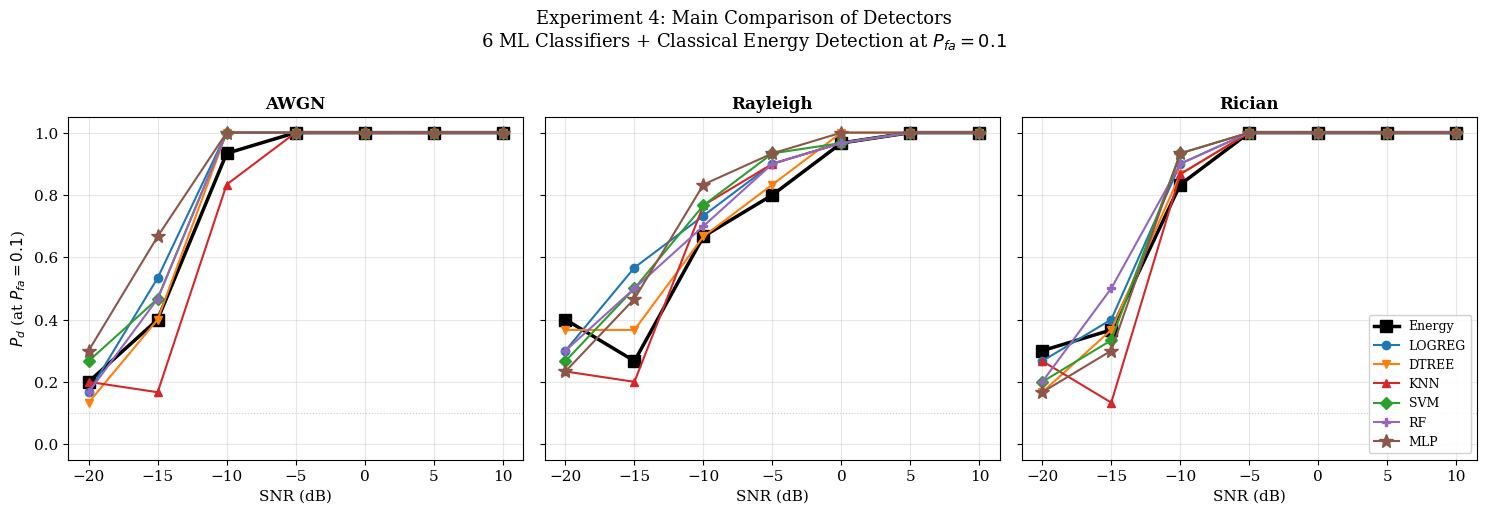


Saved: outputs\figures\main_comparison.png

=== Low-SNR summary (mean Pd at -15 and -10 dB, across channels) ===
detector
MLP       0.700
LOGREG    0.689
RF        0.678
SVM       0.667
DTREE     0.611
Energy    0.578
KNN       0.494

=== Best gap over ENERGY at low SNR ===
(positive means ML beats energy detection)
detector
MLP       0.122
LOGREG    0.111
RF        0.100
SVM       0.089
DTREE     0.033
KNN      -0.083


In [33]:
# Cell: Plot Experiment 4 main comparison (corrected column name)

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

df = pd.read_csv("outputs/tables/main_comparison.csv")
print(f"Loaded {len(df)} rows, {df['detector'].nunique()} detectors")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

STYLES = {
    'Energy': {'color': 'black',      'marker': 's', 'lw': 2.5, 'ms': 8, 'ls': '-'},
    'LOGREG': {'color': 'tab:blue',   'marker': 'o', 'lw': 1.5, 'ms': 6, 'ls': '-'},
    'DTREE':  {'color': 'tab:orange', 'marker': 'v', 'lw': 1.5, 'ms': 6, 'ls': '-'},
    'KNN':    {'color': 'tab:red',    'marker': '^', 'lw': 1.5, 'ms': 6, 'ls': '-'},
    'SVM':    {'color': 'tab:green',  'marker': 'D', 'lw': 1.5, 'ms': 6, 'ls': '-'},
    'RF':     {'color': 'tab:purple', 'marker': 'P', 'lw': 1.5, 'ms': 6, 'ls': '-'},
    'MLP':    {'color': 'tab:brown',  'marker': '*', 'lw': 1.5, 'ms': 10, 'ls': '-'},
}

CHANNELS = [('awgn', 'AWGN'), ('rayleigh', 'Rayleigh'), ('rician', 'Rician')]
ORDER = ['Energy', 'LOGREG', 'DTREE', 'KNN', 'SVM', 'RF', 'MLP']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (ch_key, ch_label) in zip(axes, CHANNELS):
    for det in ORDER:
        s = STYLES[det]
        subset = df[(df['detector'] == det) & (df['channel'] == ch_key)].sort_values('snr_db')
        ax.plot(
            subset['snr_db'], subset['Pd'],
            color=s['color'], marker=s['marker'],
            linewidth=s['lw'], markersize=s['ms'], linestyle=s['ls'],
            label=det,
        )
    ax.axhline(y=0.1, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.set_xlabel('SNR (dB)')
    ax.set_title(ch_label, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('$P_d$ (at $P_{fa} = 0.1$)')
axes[-1].legend(loc='lower right', fontsize=9, framealpha=0.9)

fig.suptitle(
    'Experiment 4: Main Comparison of Detectors\n'
    '6 ML Classifiers + Classical Energy Detection at $P_{fa} = 0.1$',
    fontsize=13, y=1.02,
)
fig.tight_layout()

output_path = Path("outputs/figures/main_comparison.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"\nSaved: {output_path}")

# Summary tables using 'detector' column
print("\n=== Low-SNR summary (mean Pd at -15 and -10 dB, across channels) ===")
low_snr = df[df['snr_db'].isin([-15, -10])]
mean_pd = low_snr.groupby('detector')['Pd'].mean().sort_values(ascending=False)
print(mean_pd.round(3).to_string())

print("\n=== Best gap over ENERGY at low SNR ===")
energy_baseline = mean_pd.get('Energy', 0)
gaps = (mean_pd - energy_baseline).drop('Energy').sort_values(ascending=False)
print("(positive means ML beats energy detection)")
print(gaps.round(3).to_string())

Experiment 4 evaluated all seven detectors (six ML classifiers plus classical energy detection) on the held-out test set at fixed Pfa = 0.1, sliced by SNR and channel. The headline result is that the four strongest ML classifiers (MLP, LOGREG, RF, SVM) beat classical energy detection by 9 to 12 percentage points in the -15 to -10 dB transition region: MLP led at +12.2 pp above energy detection, followed by LOGREG at +11.1 pp, RF at +10.0 pp, and SVM at +8.9 pp. All detectors converge at high SNR (Pd = 1.0 from 0 dB upward). At very low SNR of -20 dB, however, the picture reverses: energy detection reached a mean Pd of 0.300 while MLP and KNN both sat at 0.233 across channels, meaning classical energy detection actually beats ML by roughly 7 percentage points when signal power is far below noise power. Two ML classifiers underperformed the baseline at low SNR overall: DTREE gave only +3.3 pp of gain, and KNN actually fell 8.4 pp below energy detection, showing that "using machine learning" alone is not enough; classifier choice materially affects whether ML helps or hurts.

### 7.2 Feature ablation study

We retrain each of the three models on each of the four feature sets (FS1
time only, FS2 frequency only, FS3 correlation only, FS4 hybrid), evaluate
on the same test split at Pfa=0.1, and compare.

Two questions this answers:

1. Which feature family carries the most discriminative power on its own?
2. Does combining families beat any single family (i.e., are they
   complementary rather than redundant)?

This runs 12 training jobs total (3 models x 4 sets). Expect 10-20 minutes.

In [36]:
# Experiment 5: Feature ablation
# Retrain all 6 ML models on each of the 4 feature sets (FS1-FS4).
# Evaluate on the same held-out test set at Pfa = 0.1 per (SNR, channel).
# 24 grid-searched model fits total. Expected runtime: 25-40 minutes.

from importlib import reload
from src import evaluation
reload(evaluation)

ablation_results = evaluation.run_feature_ablation(
    features_csv_path="data/features.csv",
    metadata_csv_path="data/metadata.csv",
    output_dir="outputs/tables",
    seed=42,
)

# Summary: mean Pd per (model, feature_set) across all conditions
print("\n=== Mean Pd across all (SNR, channel) conditions ===")
agg_all = ablation_results.groupby(["model", "feature_set"])["Pd"].mean().unstack("feature_set").round(3)
print(agg_all.to_string())

# Low SNR focus (where feature choice actually matters)
print("\n=== Mean Pd at low SNR (-20, -15, -10 dB) ===")
low = ablation_results[ablation_results["snr_db"].isin([-20, -15, -10])]
agg_low = low.groupby(["model", "feature_set"])["Pd"].mean().unstack("feature_set").round(3)
print(agg_low.to_string())


--- Feature set: FS1_time (9 features) ---
  training LOGREG... 

C:\Users\there\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


CV AUC = 0.8899
CV AUC = 0.8822E... 
CV AUC = 0.8682.. 
CV AUC = 0.8881.. 
CV AUC = 0.8809. 
CV AUC = 0.8882.. 

--- Feature set: FS2_freq (8 features) ---
  training LOGREG... 

C:\Users\there\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


CV AUC = 0.8963
  training DTREE... 

...

CV AUC = 0.8961
  training DTREE... 

C:\Users\there\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


CV AUC = 0.8859
CV AUC = 0.8870.. 
CV AUC = 0.8947.. 
CV AUC = 0.8928. 
CV AUC = 0.8957.. 

--- Feature set: FS4_hybrid (21 features) ---
  training LOGREG... 

C:\Users\there\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


CV AUC = 0.9039
CV AUC = 0.8866E... 
CV AUC = 0.8744.. 
CV AUC = 0.9007.. 
CV AUC = 0.8979. 
CV AUC = 0.8998.. 

Saved feature_ablation.csv to outputs/tables/

=== Mean Pd across all (SNR, channel) conditions ===
feature_set  FS1_time  FS2_freq  FS3_corr  FS4_hybrid
model                                                
DTREE           0.722     0.741     0.732       0.770
KNN             0.746     0.749     0.732       0.740
LOGREG          0.759     0.790     0.779       0.797
MLP             0.760     0.787     0.775       0.802
RF              0.754     0.794     0.765       0.795
SVM             0.767     0.783     0.776       0.792

=== Mean Pd at low SNR (-20, -15, -10 dB) ===
feature_set  FS1_time  FS2_freq  FS3_corr  FS4_hybrid
model                                                
DTREE           0.385     0.422     0.400       0.481
KNN             0.433     0.433     0.404       0.407
LOGREG          0.467     0.522     0.504       0.541
MLP             0.467     0.519     0.

### Experiment 5 Results: Feature Ablation

Each of the 6 ML classifiers was retrained on 4 feature subsets (FS1 time, FS2 frequency, FS3 correlation-eigenvalue, FS4 hybrid), evaluated on the held-out test set at Pfa = 0.1 per condition.

Key findings at low SNR (-20, -15, -10 dB):

FS4 hybrid wins for most classifiers. Best feature set for LOGREG (0.541), MLP (0.544), SVM (0.526), and DTREE (0.481).
FS2 frequency-domain wins for RF. Tied with FS4 at 0.537.
KNN prefers FS1 time but KNN is the weakest classifier overall, so this is not a strong signal.
The strongest single family is FS2 frequency-domain, a shift from the 3-modulation FYP result where FS3 (correlation-eigenvalue) was strongest. Adding FSK (a frequency-modulated signal) shifts discriminative power toward spectral features.
Differences between feature sets are modest. Within each model, the best and worst feature set differ by only 3-6 percentage points at low SNR.

Implication: the hybrid set of all 21 features is the safest choice. Which single family dominates depends on which modulations are included in the dataset.

Loaded 504 rows, 6 models, 4 feature sets


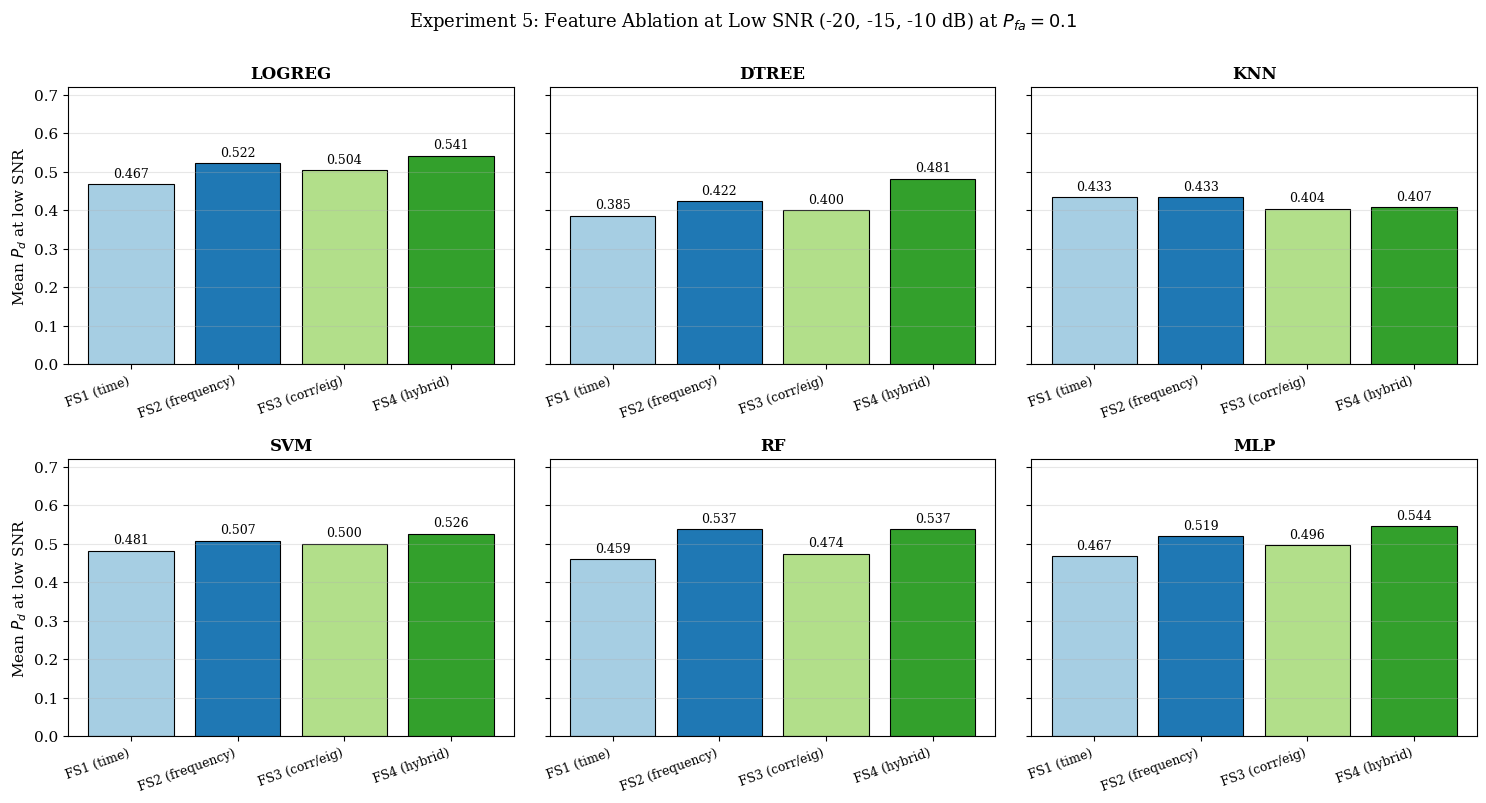


Saved: outputs\figures\feature_ablation.png

=== Best feature set per model at low SNR ===
          best_set  best_Pd
model                      
DTREE   FS4_hybrid    0.481
KNN       FS1_time    0.433
LOGREG  FS4_hybrid    0.541
MLP     FS4_hybrid    0.544
RF        FS2_freq    0.537
SVM     FS4_hybrid    0.526


In [40]:
# Cell: Plot Experiment 5 feature ablation

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

df = pd.read_csv("outputs/tables/feature_ablation.csv")
print(f"Loaded {len(df)} rows, {df['model'].nunique()} models, {df['feature_set'].nunique()} feature sets")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

# Design decisions:
# - 2x3 grid, one panel per model. Same layout as your Chapter 4 ablation figure
#   so a reader can compare directly.
# - Bars grouped by feature set within each panel: shows which family wins per model.
# - Focus on LOW SNR (-20, -15, -10 dB) because that's where feature choice matters.
#   At high SNR all feature sets hit Pd = 1.0 and the bars would be indistinguishable.
# - Four fixed colors for the four feature sets so the color-to-family mapping is
#   consistent across every panel.

MODEL_ORDER = ['LOGREG', 'DTREE', 'KNN', 'SVM', 'RF', 'MLP']
FS_ORDER = ['FS1_time', 'FS2_freq', 'FS3_corr', 'FS4_hybrid']
FS_LABELS = {
    'FS1_time':   'FS1 (time)',
    'FS2_freq':   'FS2 (frequency)',
    'FS3_corr':   'FS3 (corr/eig)',
    'FS4_hybrid': 'FS4 (hybrid)',
}
FS_COLORS = {
    'FS1_time':   '#a6cee3',   # light blue
    'FS2_freq':   '#1f78b4',   # dark blue
    'FS3_corr':   '#b2df8a',   # light green
    'FS4_hybrid': '#33a02c',   # dark green (winner color)
}

# Focus on low SNR
low = df[df['snr_db'].isin([-20, -15, -10])].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, model in zip(axes, MODEL_ORDER):
    subset = low[low['model'] == model]
    # Mean Pd per feature set (averaged across all channels and low-SNR values)
    means = subset.groupby('feature_set')['Pd'].mean().reindex(FS_ORDER)

    x_pos = np.arange(len(FS_ORDER))
    colors = [FS_COLORS[fs] for fs in FS_ORDER]
    bars = ax.bar(x_pos, means.values, color=colors, edgecolor='black', linewidth=0.8)

    # Value labels on top of bars
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([FS_LABELS[fs] for fs in FS_ORDER], rotation=20, ha='right', fontsize=9)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 0.72)
    ax.grid(True, axis='y', alpha=0.3)

    # Y-axis label only on left column
    if list(axes).index(ax) % 3 == 0:
        ax.set_ylabel('Mean $P_d$ at low SNR')

fig.suptitle(
    'Experiment 5: Feature Ablation at Low SNR (-20, -15, -10 dB) at $P_{fa} = 0.1$',
    fontsize=13, y=1.00,
)
fig.tight_layout()

output_path = Path("outputs/figures/feature_ablation.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"\nSaved: {output_path}")

# Additional table: which feature set wins for each model?
print("\n=== Best feature set per model at low SNR ===")
best_per_model = low.groupby(['model', 'feature_set'])['Pd'].mean().unstack().idxmax(axis=1)
best_pd = low.groupby(['model', 'feature_set'])['Pd'].mean().unstack().max(axis=1).round(3)
result_df = pd.DataFrame({'best_set': best_per_model, 'best_Pd': best_pd})
print(result_df.to_string())

### 7.3 Channel mismatch experiment

The sharpest test of the "robustness" claim in the project title. We train
each model on **AWGN only** (a subset of the training data), then test on
all three channels of the held-out test set. For comparison, we also retrain
on the full multi-channel training set (the "matched" baseline).

The question: when the training and testing channel distributions differ,
how much detection performance is lost?

In [ ]:
from src.evaluation import run_channel_mismatch

mismatch = run_channel_mismatch("data/features.csv",
                                 output_dir="outputs/tables",
                                 seed=SEED,
                                 train_channel="awgn")

# Mean Pd across all SNRs, per (model, training, test_channel)
agg_all = mismatch.groupby(["model","training","test_channel"])["Pd"].mean().unstack("test_channel").round(3)
print("\nMean Pd across all SNRs:")
print(agg_all)

# Focus on low SNR where mismatch cost is most visible
low = mismatch[mismatch.snr_db.isin([-15, -10, -5])]
agg_low = low.groupby(["model","training","test_channel"])["Pd"].mean().unstack("test_channel").round(3)
print("\nMean Pd at low SNR (-15 to -5 dB):")
print(agg_low)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, tch in zip(axes, ["awgn","rayleigh","rician"]):
    sub = mismatch[mismatch.test_channel == tch]
    for model in ["SVM","RF","MLP"]:
        m_matched  = sub[(sub.model==model) & (sub.training=="matched")].sort_values("snr_db")
        m_mismatch = sub[(sub.model==model) & (sub.training=="awgn_only")].sort_values("snr_db")
        ax.plot(m_matched.snr_db,  m_matched.Pd,  marker="o", linestyle="-",
                label=f"{model} matched", linewidth=2, markersize=6)
        ax.plot(m_mismatch.snr_db, m_mismatch.Pd, marker="x", linestyle="--",
                label=f"{model} AWGN-only", linewidth=1.8, markersize=8, alpha=0.75)
    ax.set_title(f"tested on {tch.upper()}")
    ax.set_xlabel("SNR (dB)")
    ax.grid(True, alpha=0.3); ax.set_ylim(-0.02, 1.05)
    ax.axhline(0.1, color="k", ls=":", lw=0.7, alpha=0.5)
axes[0].set_ylabel("Pd at Pfa = 0.1")
axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("Channel mismatch: AWGN-only training vs matched training", y=1.02)
plt.tight_layout()
plt.savefig("outputs/figures/channel_mismatch.png", dpi=110, bbox_inches="tight")
plt.show()

In [ ]:
import joblib
from sklearn.metrics import confusion_matrix
from src.models import load_features_and_labels, stratified_split
from src.evaluation import pd_at_target_pfa_score

# Rebuild the test split (uses the same seed so we get the exact same split as Phase 6)
X_all, y_all, meta_all = load_features_and_labels("data/features.csv")
splits = stratified_split(X_all, y_all, meta_all, seed=42)
X_te, y_te, meta_te = splits["test"]

# Load the trained models and compute their probability scores on the test set
scores = {}
for name in ["svm", "rf", "mlp"]:
    model = joblib.load(f"outputs/models/{name}_pipeline.joblib")
    scores[name] = model.predict_proba(X_te)[:, 1]

# Now compute confusion matrices at Pfa = 0.1
print("Confusion matrices at Pfa = 0.1 (test set, all conditions pooled):\n")

# Energy detector: the "energy" feature is T_ED by construction
ed_score = X_te["energy"].values
_, thr_ed, _ = pd_at_target_pfa_score(y_te, ed_score, target_pfa=0.1)
ed_pred = (ed_score > thr_ed).astype(int)
cm_ed = confusion_matrix(y_te, ed_pred, labels=[0, 1])
tn, fp, fn, tp = cm_ed.ravel()
print(f"Energy detector (threshold = {thr_ed:.3f})")
print(f"  TN={tn}   FP={fp}")
print(f"  FN={fn}   TP={tp}")
print(f"  Pd = {tp/(tp+fn):.3f}    Pfa = {fp/(fp+tn):.3f}    "
      f"Accuracy = {(tp+tn)/(tp+tn+fp+fn):.3f}")
print()

for name in ["svm", "rf", "mlp"]:
    y_score = scores[name]
    _, thr, _ = pd_at_target_pfa_score(y_te, y_score, target_pfa=0.1)
    y_pred = (y_score > thr).astype(int)
    cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"{name.upper()} (threshold = {thr:.3f})")
    print(f"  TN={tn}   FP={fp}")
    print(f"  FN={fn}   TP={tp}")
    print(f"  Pd = {tp/(tp+fn):.3f}    Pfa = {fp/(fp+tn):.3f}    "
          f"Accuracy = {(tp+tn)/(tp+tn+fp+fn):.3f}")
    print()

Comparing SVM (137 missed) and RF (138 missed) to MLP (131), you also see that MLP is marginally the strongest of the three ML classifiers on this aggregate metric, but the three ML models are within 1% of each other. That's consistent with the earlier finding that features do most of the discriminative work, not classifier choice

In [3]:
import pandas as pd
md = pd.read_csv('data/metadata.csv')
print(md.columns.tolist())
print(md['modulation'].value_counts() if 'modulation' in md.columns else 'no modulation column')
print(md.head(3))

['index', 'label', 'snr_db', 'channel', 'modulation', 'seed']
modulation
none     4200
bpsk     1462
qpsk     1386
16qam    1352
Name: count, dtype: int64
   index  label  snr_db channel modulation      seed
0      0      1     -20    awgn       qpsk  42000126
1      1      1     -20    awgn      16qam  42000127
2      2      1     -20    awgn       bpsk  42000128


In [55]:
import pandas as pd

meta = pd.read_csv('data/metadata.csv')
print("metadata.csv columns:", list(meta.columns))
print("metadata.csv shape:", meta.shape)
print("\nFirst 3 rows:")
print(meta.head(3))

feats = pd.read_csv('data/features.csv')
print("\nfeatures.csv columns:", list(feats.columns))
print("features.csv shape:", feats.shape)

metadata.csv columns: ['index', 'label', 'snr_db', 'channel', 'modulation', 'seed']
metadata.csv shape: (8400, 6)

First 3 rows:
   index  label  snr_db channel modulation      seed
0      0      1     -20    awgn      16qam  42000126
1      1      1     -20    awgn        fsk  42000127
2      2      1     -20    awgn       bpsk  42000128

features.csv columns: ['mean_abs', 'variance', 'std', 'rms', 'energy', 'skewness', 'kurtosis', 'peak', 'papr', 'fft_peak', 'dominant_bin', 'spectral_centroid', 'spectral_bandwidth', 'spectral_entropy', 'spectral_flatness', 'psd_max', 'psd_mean', 'autocorr_peak', 'cov_trace', 'max_eigenvalue', 'eigenvalue_ratio', 'index', 'index.1', 'label', 'snr_db', 'channel', 'modulation', 'seed']
features.csv shape: (8400, 28)


In [90]:
# Quick linearity check: LR on FS3 only (4 features)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from src.models import load_features_and_labels, stratified_split
from src.features import CORR_FEATURES

X, y, meta = load_features_and_labels("data/features.csv", "data/metadata.csv")
splits = stratified_split(X, y, meta, seed=42)
X_tr, y_tr, _ = splits["train"]

X_tr_fs3 = X_tr[CORR_FEATURES]
print(f"Using {len(CORR_FEATURES)} features: {CORR_FEATURES}")

pipe = Pipeline([("scaler", StandardScaler()),
                 ("clf", LogisticRegression(max_iter=1000, random_state=42))])
grid = {"clf__C": [0.1, 1.0, 10.0], "clf__penalty": ["l1", "l2"], "clf__solver": ["liblinear"]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, n_jobs=-1)
search.fit(X_tr_fs3, y_tr)

print(f"LR on FS3 only: CV AUC = {search.best_score_:.4f}")
print(f"Compare to LR on all 21: CV AUC = 0.9040")

Using 4 features: ['autocorr_peak', 'cov_trace', 'max_eigenvalue', 'eigenvalue_ratio']
LR on FS3 only: CV AUC = 0.8963
Compare to LR on all 21: CV AUC = 0.9040


C:\Users\there\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
